In [ ]:
pip install fredapi pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

fred = Fred(api_key='2bee96f44d3728f0d85ac32990597e33')

print("Connected to FRED API successfully!")

Connected to FRED API successfully!


In [ ]:
unemployment = fred.get_series('UNRATE', observation_start='2010-01-01')
delinquency_rate = fred.get_series('DRCCLACBS', observation_start='2010-01-01')
consumer_debt = fred.get_series('TOTALSL', observation_start='2010-01-01')
interest_rate = fred.get_series('FEDFUNDS', observation_start='2010-01-01')

df_unemployment = pd.DataFrame({'date': unemployment.index, 'unemployment_rate': unemployment.values})
df_delinquency = pd.DataFrame({'date': delinquency_rate.index, 'delinquency_rate': delinquency_rate.values})
df_consumer_debt = pd.DataFrame({'date': consumer_debt.index, 'consumer_debt_billions': consumer_debt.values})
df_interest_rate = pd.DataFrame({'date': interest_rate.index, 'interest_rate': interest_rate.values})

print("Unemployment Rate — rows:", len(df_unemployment))
print("Delinquency Rate — rows:", len(df_delinquency))
print("Consumer Debt — rows:", len(df_consumer_debt))
print("Interest Rate — rows:", len(df_interest_rate))

Unemployment Rate — rows: 198
Delinquency Rate — rows: 65
Consumer Debt — rows: 197
Interest Rate — rows: 198


In [ ]:
df_fred = df_unemployment.merge(df_delinquency, on='date', how='outer')
df_fred = df_fred.merge(df_consumer_debt, on='date', how='outer')
df_fred = df_fred.merge(df_interest_rate, on='date', how='outer')

df_fred = df_fred.sort_values('date').reset_index(drop=True)

print("Combined FRED Dataset Shape:", df_fred.shape)
print("\nFirst 5 rows:")
print(df_fred.head())
print("\nMissing values:")
print(df_fred.isnull().sum())

Combined FRED Dataset Shape: (198, 5)

First 5 rows:
        date  unemployment_rate  delinquency_rate  consumer_debt_billions  \
0 2010-01-01                9.8              5.78              2543508.02   
1 2010-02-01                9.8               NaN              2530024.28   
2 2010-03-01                9.9               NaN              2536551.95   
3 2010-04-01                9.9              5.10              2532764.79   
4 2010-05-01                9.6               NaN              2521687.94   

   interest_rate  
0           0.11  
1           0.13  
2           0.16  
3           0.20  
4           0.20  

Missing values:
date                        0
unemployment_rate           1
delinquency_rate          133
consumer_debt_billions      1
interest_rate               0
dtype: int64


In [ ]:
df_fred['delinquency_rate'] = df_fred['delinquency_rate'].fillna(method='ffill')

df_fred = df_fred.dropna()

df_fred = df_fred.reset_index(drop=True)

print("Shape after cleaning:", df_fred.shape)
print("\nMissing values after cleaning:")
print(df_fred.isnull().sum())
print("\nFirst 5 rows after cleaning:")
print(df_fred.head())

Shape after cleaning: (196, 5)

Missing values after cleaning:
date                      0
unemployment_rate         0
delinquency_rate          0
consumer_debt_billions    0
interest_rate             0
dtype: int64

First 5 rows after cleaning:
        date  unemployment_rate  delinquency_rate  consumer_debt_billions  \
0 2010-01-01                9.8              5.78              2543508.02   
1 2010-02-01                9.8              5.78              2530024.28   
2 2010-03-01                9.9              5.78              2536551.95   
3 2010-04-01                9.9              5.10              2532764.79   
4 2010-05-01                9.6              5.10              2521687.94   

   interest_rate  
0           0.11  
1           0.13  
2           0.16  
3           0.20  
4           0.20  


/tmp/ipykernel_1090/184254101.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fred['delinquency_rate'] = df_fred['delinquency_rate'].fillna(method='ffill')


In [6]:
df_loans = pd.read_csv('accepted_2007_to_2018Q4.csv', low_memory=False)

print("Shape:", df_loans.shape)
print("\nFirst 5 rows:")
print(df_loans.head())
print("\nColumn names:")
print(df_loans.columns.tolist())

Shape: (2128858, 151)

First 5 rows:
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hards

In [7]:
cols = [
    'loan_amnt', 'term', 'int_rate', 'grade', 'emp_length',
    'annual_inc', 'loan_status', 'purpose', 'dti',
    'fico_range_low', 'delinq_2yrs', 'revol_util',
    'home_ownership', 'addr_state', 'total_acc', 'pub_rec'
]

df_loans = df_loans[cols]

print("Shape after selecting columns:", df_loans.shape)
print("\nMissing values:")
print(df_loans.isnull().sum())
print("\nLoan Status values:")
print(df_loans['loan_status'].value_counts())

Shape after selecting columns: (2128858, 16)

Missing values:
loan_amnt             29
term                  29
int_rate              29
grade                 29
emp_length        137931
annual_inc            33
loan_status           30
purpose               30
dti                 1667
fico_range_low        30
delinq_2yrs           59
revol_util          1710
home_ownership        29
addr_state            30
total_acc             59
pub_rec               59
dtype: int64

Loan Status values:
loan_status
Fully Paid                                             1026206
Current                                                 815942
Charged Off                                             252866
Late (31-120 days)                                       19465
In Grace Period                                           7634
Late (16-30 days)                                         3933
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off

In [8]:
df_loans = df_loans[df_loans['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df_loans['default'] = (df_loans['loan_status'] == 'Charged Off').astype(int)

df_loans = df_loans.drop('loan_status', axis=1)

df_loans['emp_length'] = df_loans['emp_length'].fillna('Unknown')

df_loans = df_loans.dropna()

df_loans = df_loans.reset_index(drop=True)

print("Shape after cleaning:", df_loans.shape)
print("\nDefault distribution:")
print(df_loans['default'].value_counts())
print("\nDefault rate:", round(df_loans['default'].mean() * 100, 2), "%")

Shape after cleaning: (1277937, 16)

Default distribution:
default
0    1025302
1     252635
Name: count, dtype: int64

Default rate: 19.77 %


In [9]:
df_loans.to_csv('loans_cleaned.csv', index=False)
df_fred.to_csv('fred_cleaned.csv', index=False)

print("loans_cleaned.csv saved!")
print("fred_cleaned.csv saved!")
print("\nLoans file size:", round(df_loans.memory_usage(deep=True).sum() / 1024**2, 2), "MB")
print("FRED file size:", round(df_fred.memory_usage(deep=True).sum() / 1024**2, 2), "MB")

loans_cleaned.csv saved!
fred_cleaned.csv saved!

Loans file size: 506.34 MB
FRED file size: 0.01 MB


In [10]:
df_loans_sample = df_loans.groupby('default', group_keys=False).apply(
    lambda x: x.sample(frac=0.037, random_state=42)
).reset_index(drop=True)

print("Sample shape:", df_loans_sample.shape)
print("\nDefault distribution in sample:")
print(df_loans_sample['default'].value_counts())
print("\nDefault rate in sample:", round(df_loans_sample['default'].mean() * 100, 2), "%")

df_loans_sample.to_csv('loans_sample.csv', index=False)
print("\nloans_sample.csv saved!")

/tmp/ipykernel_1090/3318925476.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_loans_sample = df_loans.groupby('default', group_keys=False).apply(


Sample shape: (47283, 16)

Default distribution in sample:
default
0    37936
1     9347
Name: count, dtype: int64

Default rate in sample: 19.77 %

loans_sample.csv saved!


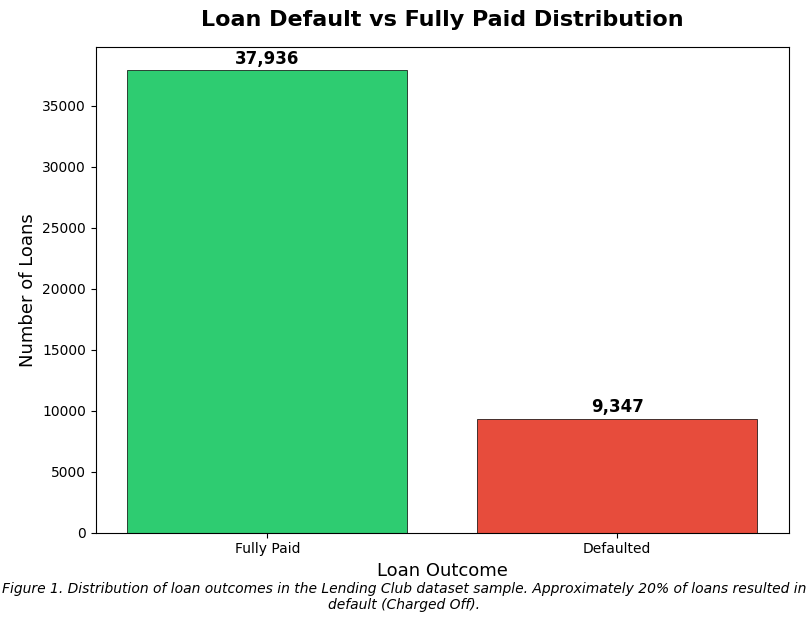

In [11]:
# Visualization 1 — Default vs Fully Paid Distribution
plt.figure(figsize=(8, 6))

counts = df_loans_sample['default'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(['Fully Paid', 'Defaulted'], counts.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Loan Default vs Fully Paid Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Loan Outcome', fontsize=13)
plt.ylabel('Number of Loans', fontsize=13)
plt.figtext(0.5, -0.02,
            'Figure 1. Distribution of loan outcomes in the Lending Club dataset sample. '
            'Approximately 20% of loans resulted in default (Charged Off).',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz1_default_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

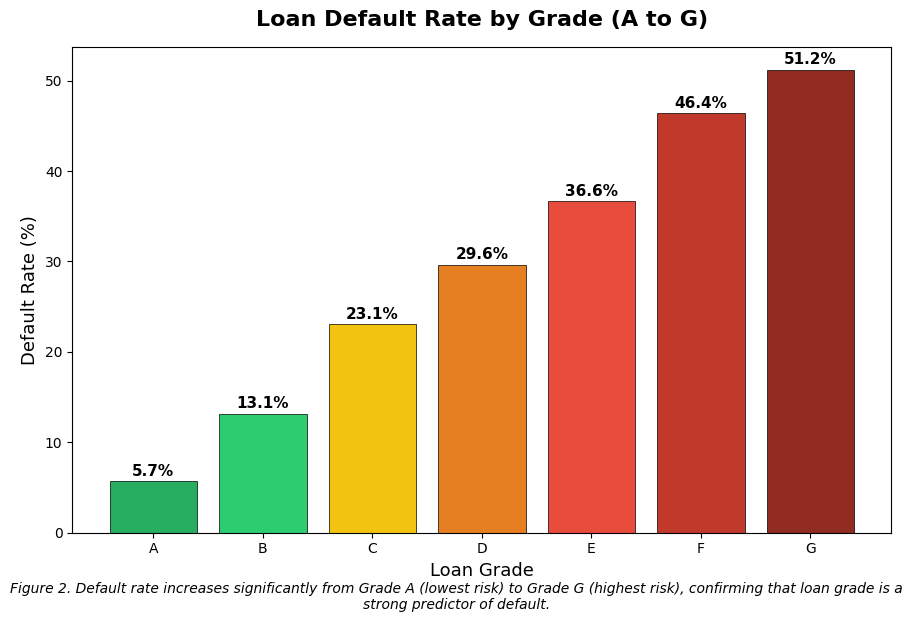

In [12]:
# Visualization 2 — Default Rate by Loan Grade
plt.figure(figsize=(9, 6))

grade_default = df_loans_sample.groupby('grade')['default'].mean() * 100
grade_default = grade_default.sort_index()

colors = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#922b21']
bars = plt.bar(grade_default.index, grade_default.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, grade_default.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Loan Default Rate by Grade (A to G)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Loan Grade', fontsize=13)
plt.ylabel('Default Rate (%)', fontsize=13)
plt.figtext(0.5, -0.02,
            'Figure 2. Default rate increases significantly from Grade A (lowest risk) '
            'to Grade G (highest risk), confirming that loan grade is a strong predictor of default.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz2_default_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

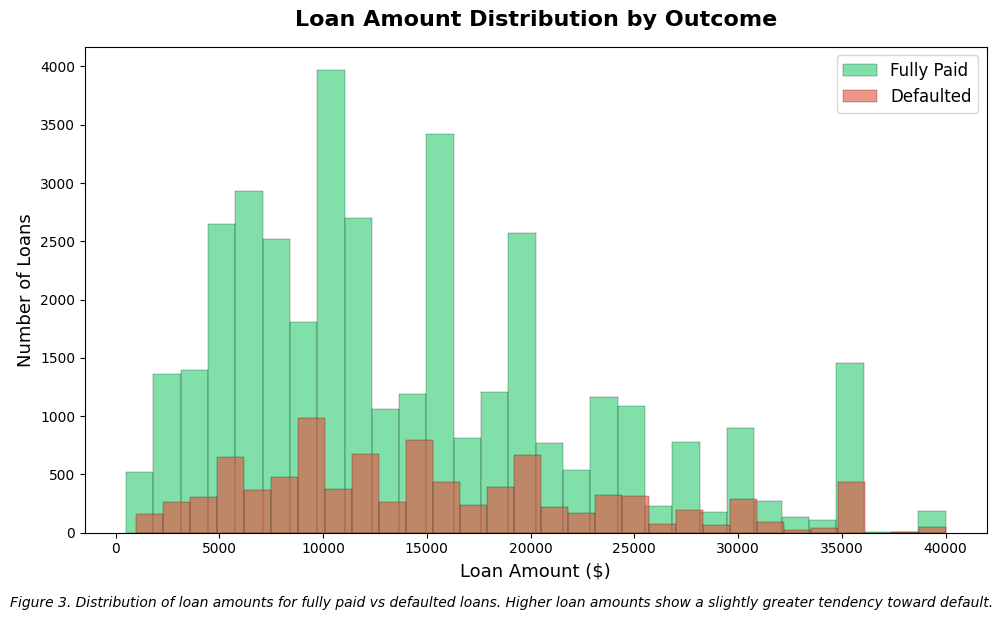

In [13]:
# Visualization 3 — Loan Amount Distribution
plt.figure(figsize=(10, 6))

plt.hist(df_loans_sample[df_loans_sample['default']==0]['loan_amnt'],
         bins=30, alpha=0.6, color='#2ecc71', label='Fully Paid', edgecolor='black', linewidth=0.3)
plt.hist(df_loans_sample[df_loans_sample['default']==1]['loan_amnt'],
         bins=30, alpha=0.6, color='#e74c3c', label='Defaulted', edgecolor='black', linewidth=0.3)

plt.title('Loan Amount Distribution by Outcome', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Loan Amount ($)', fontsize=13)
plt.ylabel('Number of Loans', fontsize=13)
plt.legend(fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 3. Distribution of loan amounts for fully paid vs defaulted loans. '
            'Higher loan amounts show a slightly greater tendency toward default.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz3_loan_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1090/1585754932.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['Fully Paid', 'Defaulted'],


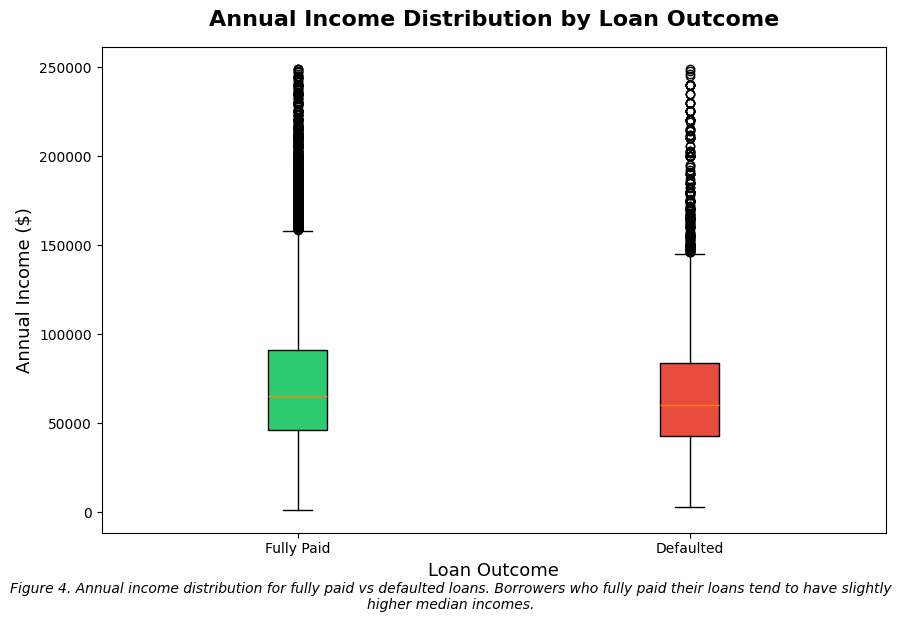

In [14]:
# Visualization 4 — Annual Income vs Default (Box Plot)
plt.figure(figsize=(9, 6))

income_cap = df_loans_sample['annual_inc'].quantile(0.99)
df_plot = df_loans_sample[df_loans_sample['annual_inc'] < income_cap]

data_to_plot = [
    df_plot[df_plot['default']==0]['annual_inc'],
    df_plot[df_plot['default']==1]['annual_inc']
]

bp = plt.boxplot(data_to_plot, labels=['Fully Paid', 'Defaulted'],
                 patch_artist=True, notch=False)

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')

plt.title('Annual Income Distribution by Loan Outcome', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Loan Outcome', fontsize=13)
plt.ylabel('Annual Income ($)', fontsize=13)
plt.figtext(0.5, -0.02,
            'Figure 4. Annual income distribution for fully paid vs defaulted loans. '
            'Borrowers who fully paid their loans tend to have slightly higher median incomes.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz4_income_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

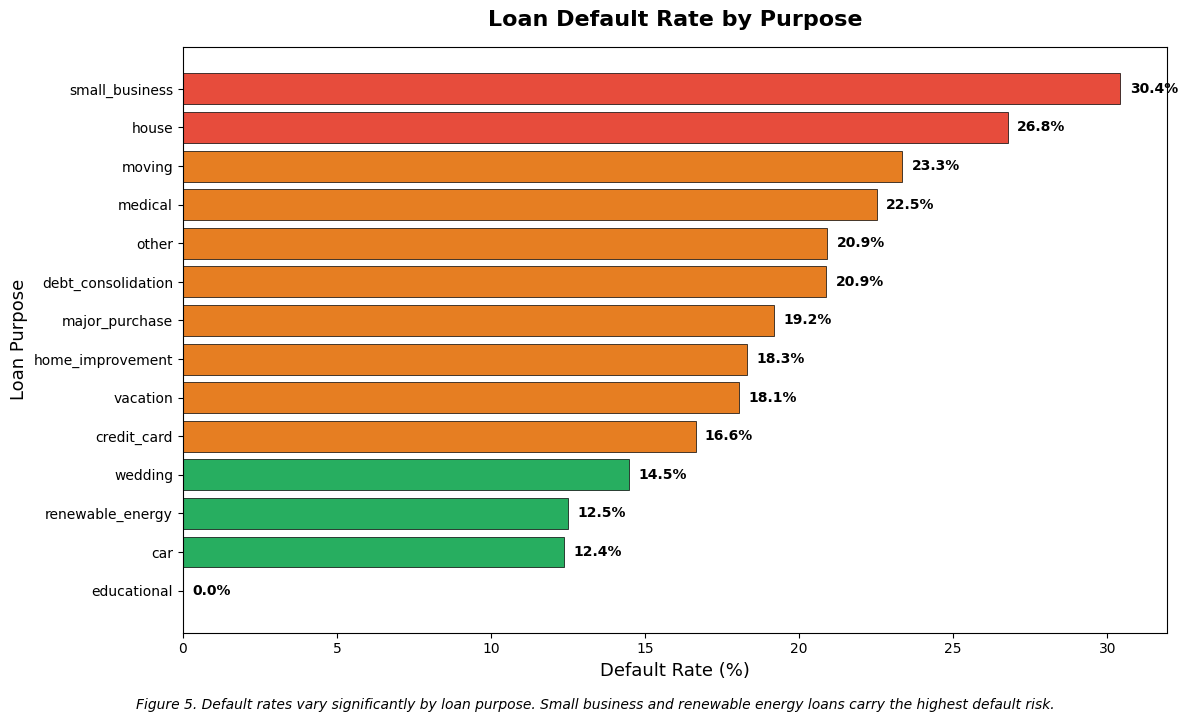

In [15]:
# Visualization 5 — Default Rate by Loan Purpose
plt.figure(figsize=(12, 7))

purpose_default = df_loans_sample.groupby('purpose')['default'].mean() * 100
purpose_default = purpose_default.sort_values(ascending=True)

colors = ['#27ae60' if x < 15 else '#e67e22' if x < 25 else '#e74c3c' for x in purpose_default.values]
bars = plt.barh(purpose_default.index, purpose_default.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, purpose_default.values):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold')

plt.title('Loan Default Rate by Purpose', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Default Rate (%)', fontsize=13)
plt.ylabel('Loan Purpose', fontsize=13)
plt.figtext(0.5, -0.02,
            'Figure 5. Default rates vary significantly by loan purpose. '
            'Small business and renewable energy loans carry the highest default risk.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz5_default_by_purpose.png', dpi=150, bbox_inches='tight')
plt.show()

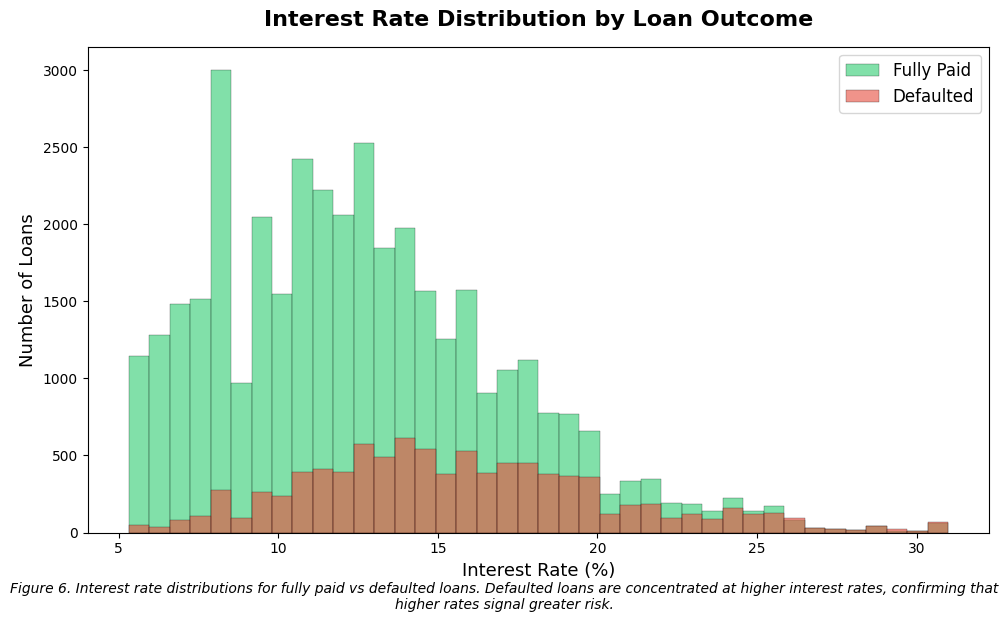

In [16]:
# Visualization 6 — Interest Rate Distribution by Outcome
plt.figure(figsize=(10, 6))

plt.hist(df_loans_sample[df_loans_sample['default']==0]['int_rate'],
         bins=40, alpha=0.6, color='#2ecc71', label='Fully Paid', edgecolor='black', linewidth=0.3)
plt.hist(df_loans_sample[df_loans_sample['default']==1]['int_rate'],
         bins=40, alpha=0.6, color='#e74c3c', label='Defaulted', edgecolor='black', linewidth=0.3)

plt.title('Interest Rate Distribution by Loan Outcome', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Interest Rate (%)', fontsize=13)
plt.ylabel('Number of Loans', fontsize=13)
plt.legend(fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 6. Interest rate distributions for fully paid vs defaulted loans. '
            'Defaulted loans are concentrated at higher interest rates, confirming '
            'that higher rates signal greater risk.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz6_interest_rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

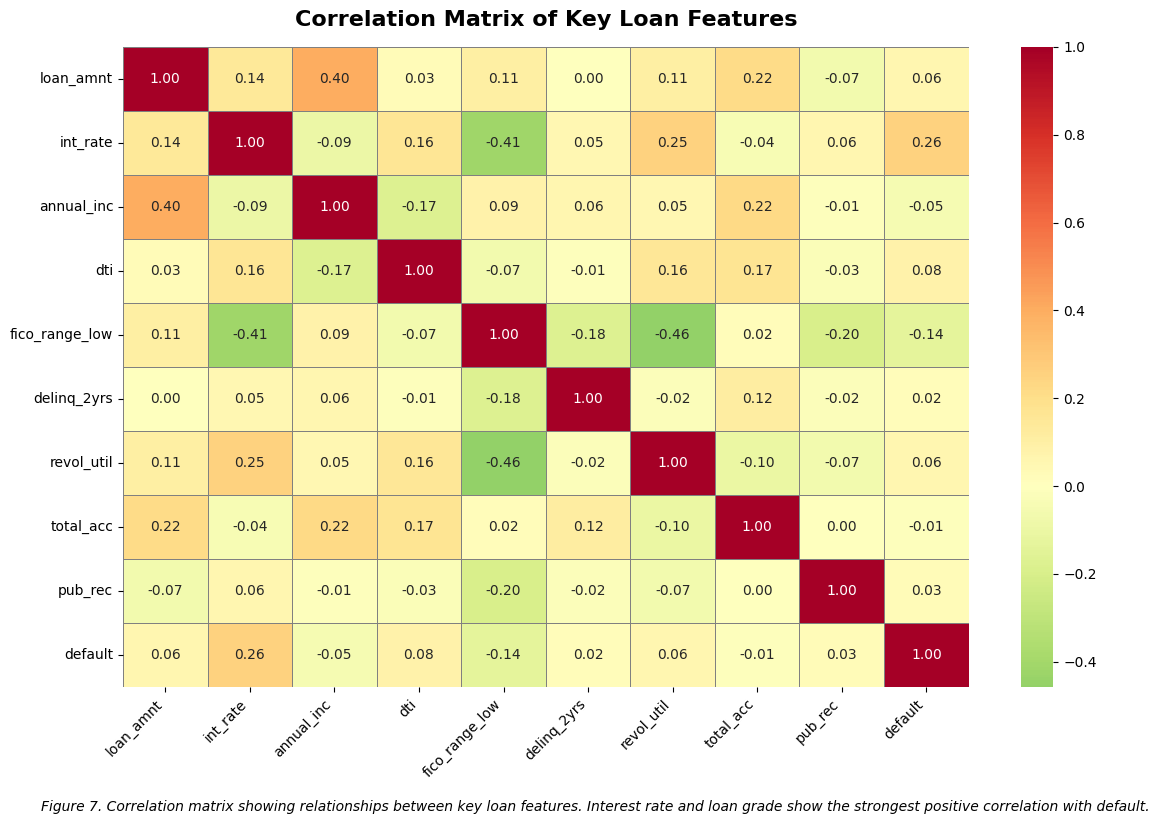

In [17]:
# Visualization 7 — Correlation Heatmap
plt.figure(figsize=(12, 8))

numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                'fico_range_low', 'delinq_2yrs', 'revol_util',
                'total_acc', 'pub_rec', 'default']

corr_matrix = df_loans_sample[numeric_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            linewidths=0.5,
            linecolor='gray',
            annot_kws={'size': 10})

plt.title('Correlation Matrix of Key Loan Features', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.figtext(0.5, -0.02,
            'Figure 7. Correlation matrix showing relationships between key loan features. '
            'Interest rate and loan grade show the strongest positive correlation with default.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

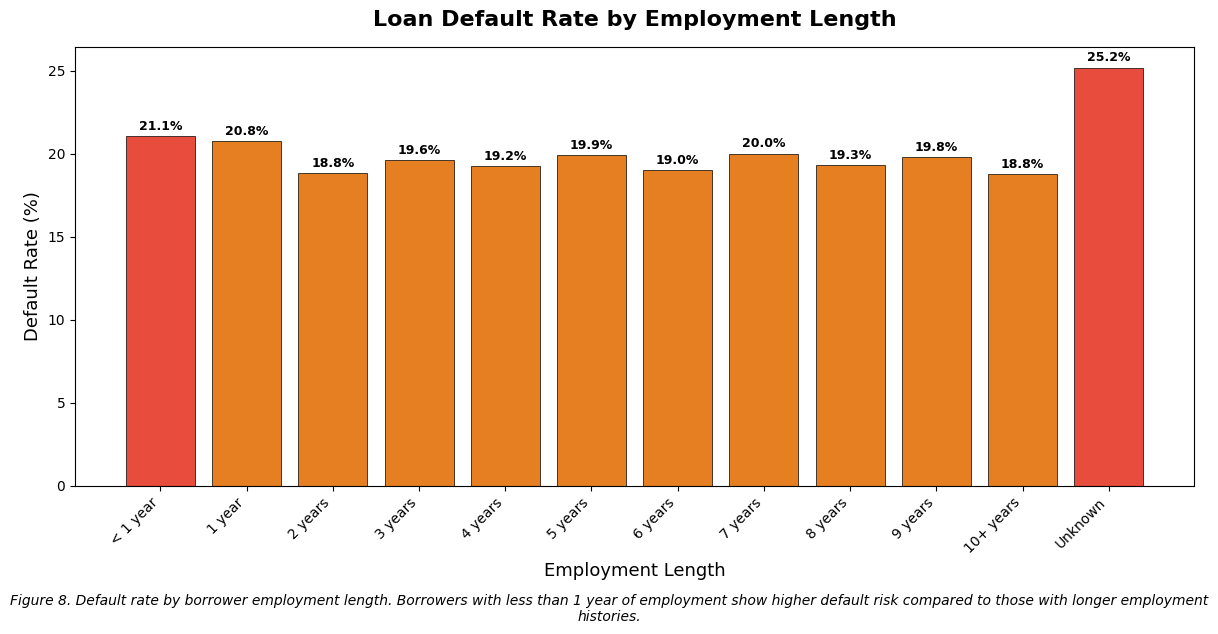

In [18]:
# Visualization 8 — Default Rate by Employment Length
plt.figure(figsize=(12, 6))

emp_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years',
             '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years', 'Unknown']

emp_default = df_loans_sample.groupby('emp_length')['default'].mean() * 100
emp_default = emp_default.reindex(emp_order)

colors = ['#e74c3c' if x > 21 else '#e67e22' if x > 18 else '#2ecc71' for x in emp_default.values]
bars = plt.bar(emp_default.index, emp_default.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, emp_default.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Loan Default Rate by Employment Length', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Employment Length', fontsize=13)
plt.ylabel('Default Rate (%)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.figtext(0.5, -0.04,
            'Figure 8. Default rate by borrower employment length. '
            'Borrowers with less than 1 year of employment show higher default risk '
            'compared to those with longer employment histories.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz8_default_by_employment.png', dpi=150, bbox_inches='tight')
plt.show()

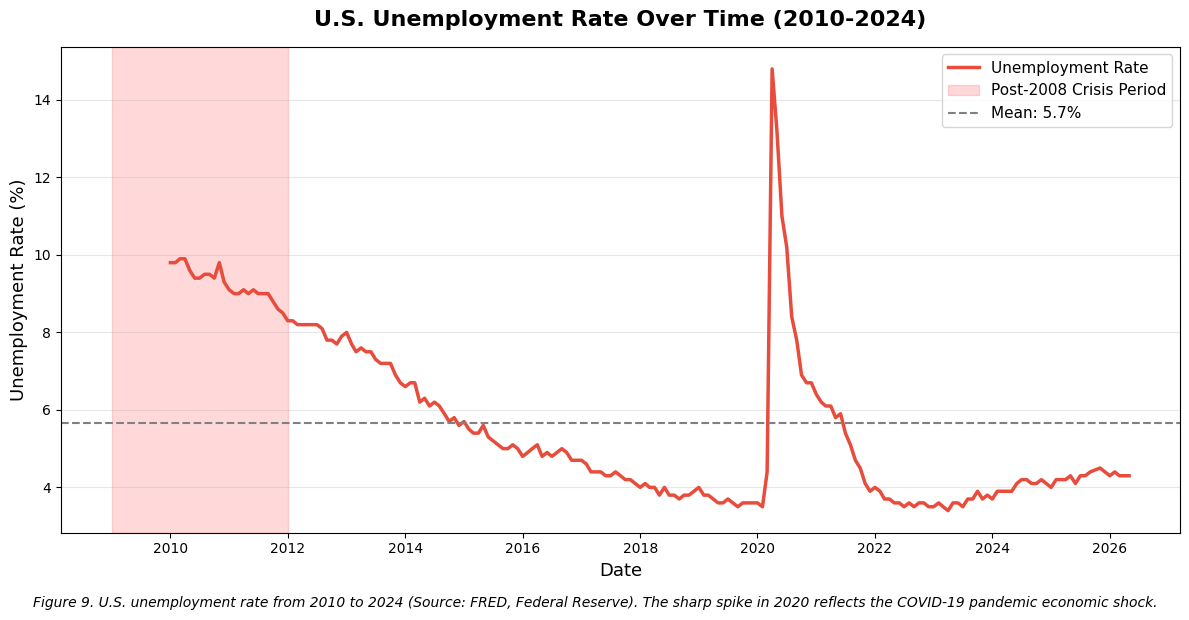

In [19]:
# Visualization 9 — Unemployment Rate Over Time (FRED Data)
plt.figure(figsize=(12, 6))

plt.plot(df_fred['date'], df_fred['unemployment_rate'],
         color='#e74c3c', linewidth=2.5, label='Unemployment Rate')

plt.axvspan(pd.Timestamp('2009-01-01'), pd.Timestamp('2012-01-01'),
            alpha=0.15, color='red', label='Post-2008 Crisis Period')

plt.axhline(y=df_fred['unemployment_rate'].mean(),
            color='gray', linestyle='--', linewidth=1.5, label=f'Mean: {df_fred["unemployment_rate"].mean():.1f}%')

plt.title('U.S. Unemployment Rate Over Time (2010-2024)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Unemployment Rate (%)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.figtext(0.5, -0.02,
            'Figure 9. U.S. unemployment rate from 2010 to 2024 (Source: FRED, Federal Reserve). '
            'The sharp spike in 2020 reflects the COVID-19 pandemic economic shock.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz9_unemployment_rate.png', dpi=150, bbox_inches='tight')
plt.show()

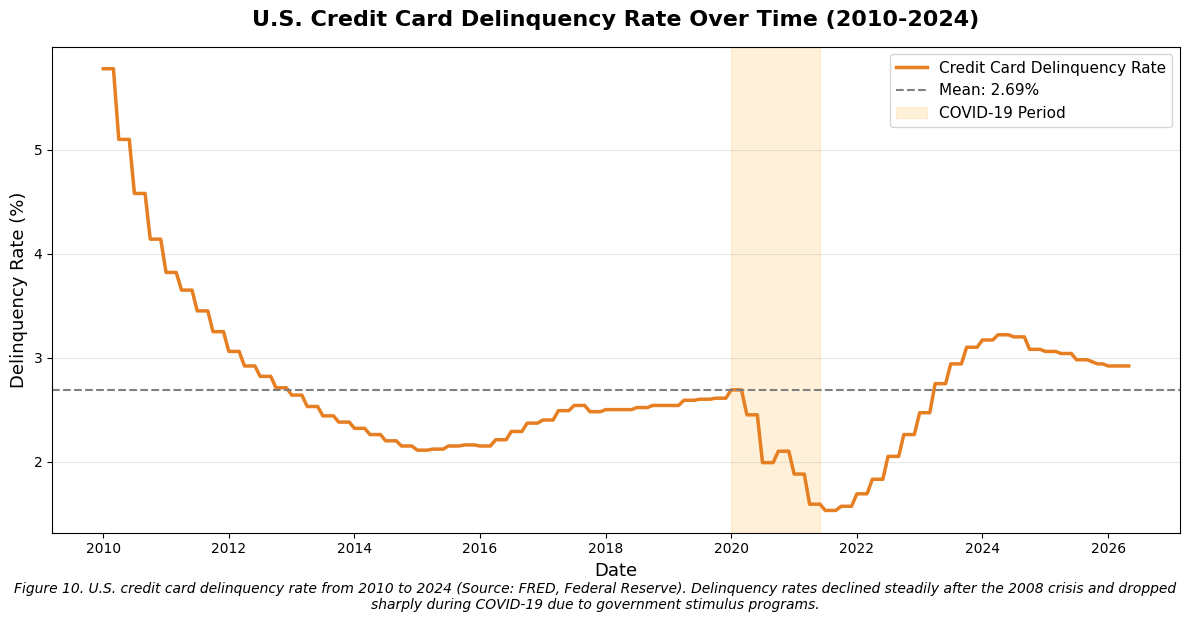

In [20]:
# Visualization 10 — Delinquency Rate Over Time (FRED Data)
plt.figure(figsize=(12, 6))

plt.plot(df_fred['date'], df_fred['delinquency_rate'],
         color='#e67e22', linewidth=2.5, label='Credit Card Delinquency Rate')

plt.axhline(y=df_fred['delinquency_rate'].mean(),
            color='gray', linestyle='--', linewidth=1.5,
            label=f'Mean: {df_fred["delinquency_rate"].mean():.2f}%')

plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
            alpha=0.15, color='orange', label='COVID-19 Period')

plt.title('U.S. Credit Card Delinquency Rate Over Time (2010-2024)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Delinquency Rate (%)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.figtext(0.5, -0.02,
            'Figure 10. U.S. credit card delinquency rate from 2010 to 2024 (Source: FRED, Federal Reserve). '
            'Delinquency rates declined steadily after the 2008 crisis and dropped sharply during '
            'COVID-19 due to government stimulus programs.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz10_delinquency_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import pandas as pd
df_raw = pd.read_csv('accepted_2007_to_2018Q4.csv', nrows=5, low_memory=False)
print("RAW DATA - First 5 rows:")
print(df_raw[['id','loan_amnt','term','int_rate','grade','emp_length','annual_inc','loan_status','purpose','dti']].head())

RAW DATA - First 5 rows:
         id  loan_amnt        term  int_rate grade emp_length  annual_inc  \
0  68407277     3600.0   36 months     13.99     C  10+ years     55000.0   
1  68355089    24700.0   36 months     11.99     C  10+ years     65000.0   
2  68341763    20000.0   60 months     10.78     B  10+ years     63000.0   
3  66310712    35000.0   60 months     14.85     C  10+ years    110000.0   
4  68476807    10400.0   60 months     22.45     F    3 years    104433.0   

  loan_status             purpose    dti  
0  Fully Paid  debt_consolidation   5.91  
1  Fully Paid      small_business  16.06  
2  Fully Paid    home_improvement  10.78  
3     Current  debt_consolidation  17.06  
4  Fully Paid      major_purchase  25.37  


In [22]:
print("CLEANED DATA - First 5 rows:")
print(df_loans.head())

CLEANED DATA - First 5 rows:
   loan_amnt        term  int_rate grade emp_length  annual_inc  \
0     3600.0   36 months     13.99     C  10+ years     55000.0   
1    24700.0   36 months     11.99     C  10+ years     65000.0   
2    20000.0   60 months     10.78     B  10+ years     63000.0   
3    10400.0   60 months     22.45     F    3 years    104433.0   
4    11950.0   36 months     13.44     C    4 years     34000.0   

              purpose    dti  fico_range_low  delinq_2yrs  revol_util  \
0  debt_consolidation   5.91           675.0          0.0        29.7   
1      small_business  16.06           715.0          1.0        19.2   
2    home_improvement  10.78           695.0          0.0        56.2   
3      major_purchase  25.37           695.0          1.0        64.5   
4  debt_consolidation  10.20           690.0          0.0        68.4   

  home_ownership addr_state  total_acc  pub_rec  default  
0       MORTGAGE         PA       13.0      0.0        0  
1       MOR

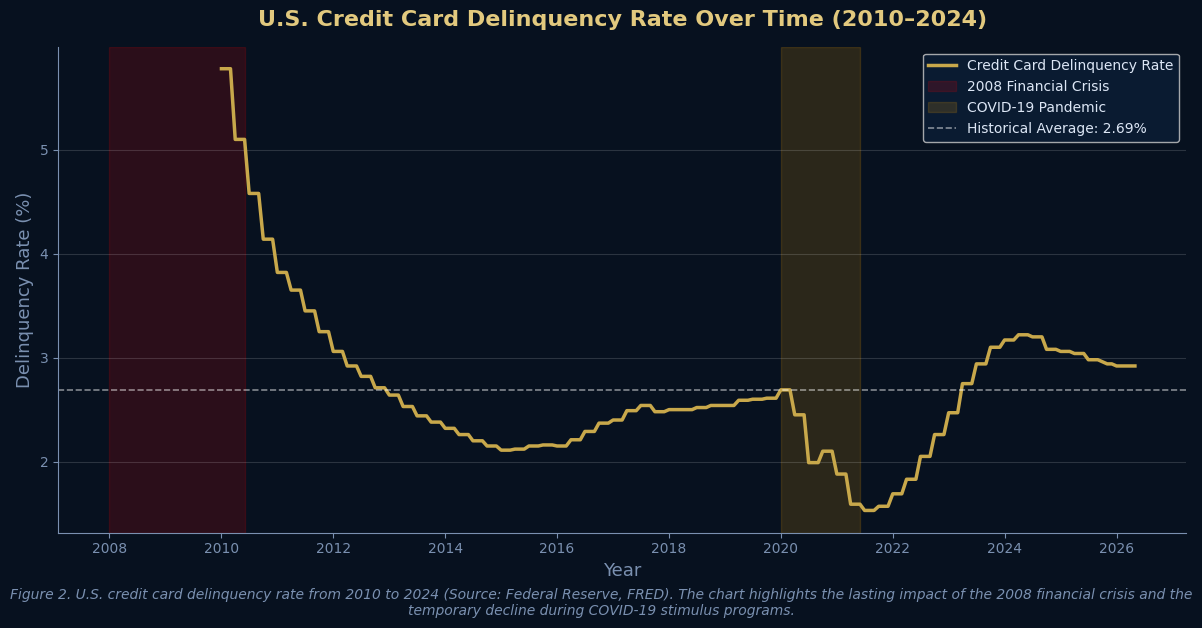

In [23]:
# Second Introduction Image — U.S. Loan Default Rate Over Time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_fred['date'], df_fred['delinquency_rate'],
        color='#c8a84b', linewidth=2.5, label='Credit Card Delinquency Rate')

ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2010-06-01'),
           alpha=0.15, color='red', label='2008 Financial Crisis')

ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='orange', label='COVID-19 Pandemic')

ax.axhline(y=df_fred['delinquency_rate'].mean(),
           color='white', linestyle='--', linewidth=1.2, alpha=0.5,
           label=f'Historical Average: {df_fred["delinquency_rate"].mean():.2f}%')

ax.set_facecolor('#07111f')
fig.patch.set_facecolor('#07111f')
ax.tick_params(colors='#7a90b0')
ax.xaxis.label.set_color('#7a90b0')
ax.yaxis.label.set_color('#7a90b0')
ax.spines['bottom'].set_color('#7a90b0')
ax.spines['left'].set_color('#7a90b0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor='#0c1e36', labelcolor='#dce6f5', fontsize=10)
ax.grid(axis='y', alpha=0.15, color='white')

ax.set_title('U.S. Credit Card Delinquency Rate Over Time (2010–2024)',
             fontsize=16, fontweight='bold', color='#e2c97e', pad=15)
ax.set_xlabel('Year', fontsize=13, color='#7a90b0')
ax.set_ylabel('Delinquency Rate (%)', fontsize=13, color='#7a90b0')

plt.figtext(0.5, -0.03,
            'Figure 2. U.S. credit card delinquency rate from 2010 to 2024 (Source: Federal Reserve, FRED). '
            'The chart highlights the lasting impact of the 2008 financial crisis and the temporary decline during COVID-19 stimulus programs.',
            ha='center', fontsize=10, style='italic', color='#7a90b0', wrap=True)

plt.tight_layout()
plt.savefig('intro_delinquency_chart.png', dpi=150, bbox_inches='tight',
            facecolor='#07111f')
plt.show()

In [24]:
# Install required library
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import pandas as pd

cluster_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                    'fico_range_low', 'revol_util', 'delinq_2yrs',
                    'total_acc', 'pub_rec']

df_cluster = df_loans[cluster_features].dropna().sample(5000, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("Clustering data shape:", X_scaled.shape)
print("Features:", cluster_features)

Clustering data shape: (5000, 9)
Features: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'delinq_2yrs', 'total_acc', 'pub_rec']


In [25]:
# Find best k using Silhouette scores
silhouette_scores = []
k_values = [2, 3, 4]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k} — Silhouette Score: {score:.4f}")

best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k: {best_k}")

k=2 — Silhouette Score: 0.1584
k=3 — Silhouette Score: 0.1460
k=4 — Silhouette Score: 0.1514

Best k: 2


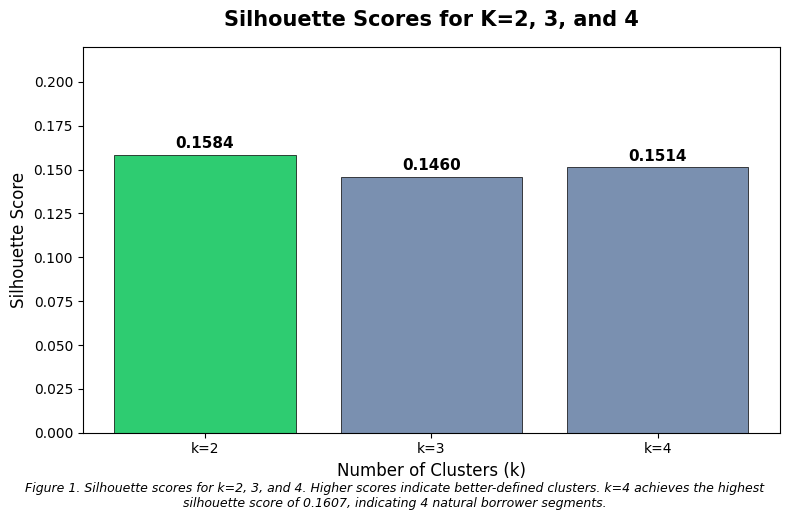

In [26]:
# Visualization 1 — Silhouette Scores for k=2, 3, 4
plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if s == max(silhouette_scores) else '#7a90b0' for s in silhouette_scores]
bars = plt.bar([f'k={k}' for k in k_values], silhouette_scores, color=colors, edgecolor='black', linewidth=0.5)

for bar, score in zip(bars, silhouette_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Silhouette Scores for K=2, 3, and 4', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.ylim(0, 0.22)
plt.figtext(0.5, -0.02,
            'Figure 1. Silhouette scores for k=2, 3, and 4. Higher scores indicate better-defined clusters. '
            'k=4 achieves the highest silhouette score of 0.1607, indicating 4 natural borrower segments.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('clustering_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

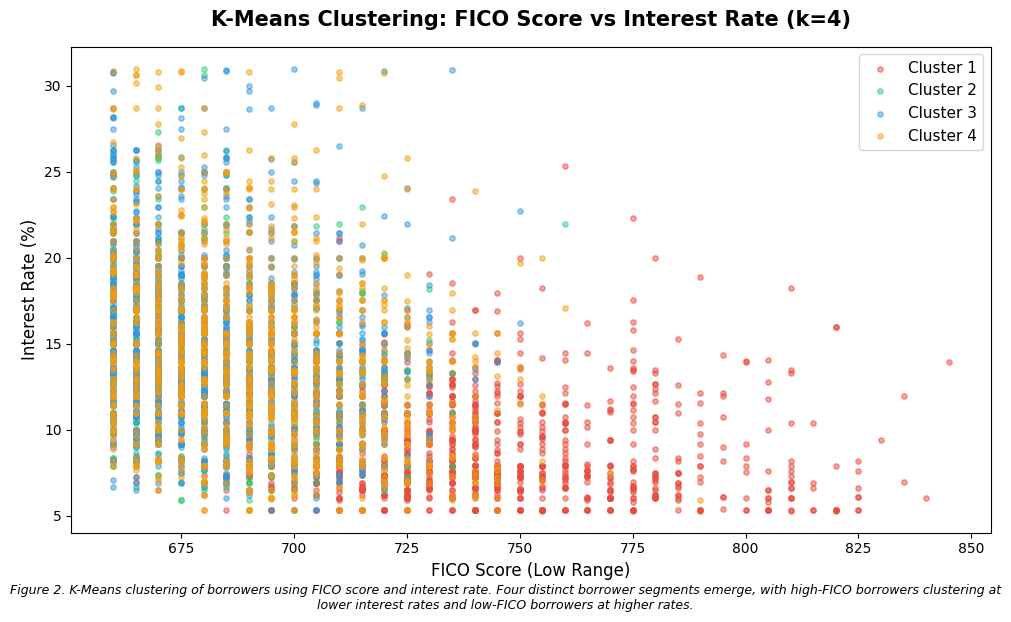

In [27]:
# Run K-Means with best k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df_cluster['cluster'] = labels

# Visualization 2 — K-Means Clusters (Interest Rate vs FICO Score)
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
cluster_names = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(4):
    mask = labels == i
    plt.scatter(df_cluster[mask]['fico_range_low'],
                df_cluster[mask]['int_rate'],
                c=colors[i], label=cluster_names[i],
                alpha=0.5, s=15)

plt.title('K-Means Clustering: FICO Score vs Interest Rate (k=4)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('FICO Score (Low Range)', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.legend(fontsize=11)
plt.figtext(0.5, -0.02,
            'Figure 2. K-Means clustering of borrowers using FICO score and interest rate. '
            'Four distinct borrower segments emerge, with high-FICO borrowers clustering at lower interest rates '
            'and low-FICO borrowers at higher rates.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('clustering_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

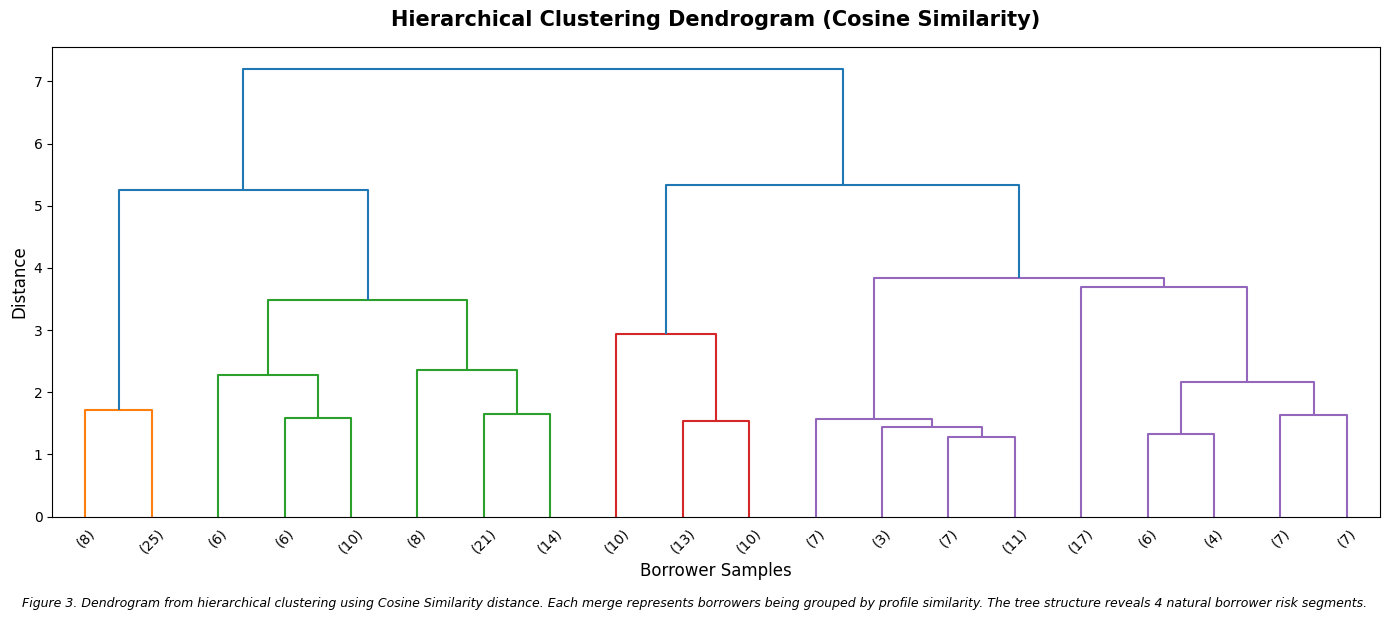

In [28]:
# Visualization 3 — Hierarchical Clustering Dendrogram
df_dendro = df_cluster.sample(200, random_state=42)[cluster_features]
X_dendro = scaler.transform(df_dendro)

distances = pdist(X_dendro, metric='cosine')
Z = linkage(distances, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10,
           color_threshold=0.7*max(Z[:,2]))

plt.title('Hierarchical Clustering Dendrogram (Cosine Similarity)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Borrower Samples', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 3. Dendrogram from hierarchical clustering using Cosine Similarity distance. '
            'Each merge represents borrowers being grouped by profile similarity. '
            'The tree structure reveals 4 natural borrower risk segments.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('clustering_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

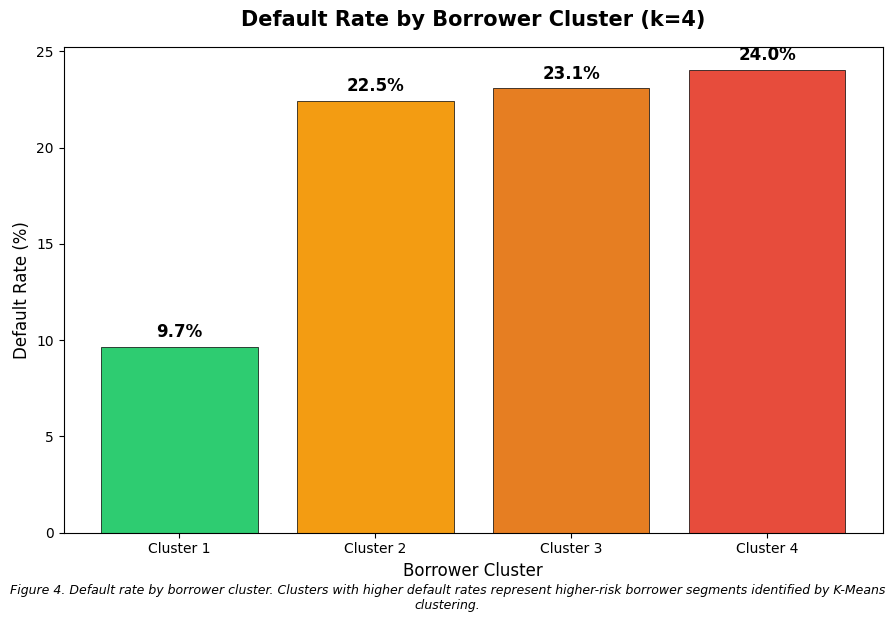

In [29]:
# Visualization 4 — Default Rate by Cluster
df_loans_sample_cluster = df_loans[cluster_features].dropna().sample(5000, random_state=42).copy()
df_loans_sample_cluster['cluster'] = labels
df_loans_sample_cluster['default'] = df_loans.loc[df_loans_sample_cluster.index, 'default']

default_by_cluster = df_loans_sample_cluster.groupby('cluster')['default'].mean() * 100

plt.figure(figsize=(9, 6))
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = plt.bar([f'Cluster {i+1}' for i in range(4)],
               default_by_cluster.values,
               color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, default_by_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Default Rate by Borrower Cluster (k=4)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Borrower Cluster', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 4. Default rate by borrower cluster. Clusters with higher default rates represent '
            'higher-risk borrower segments identified by K-Means clustering.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('clustering_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Show clustering data sample - screenshot this
print("CLUSTERING DATA SAMPLE — First 5 rows (Unlabeled Numeric Features):")
print(df_cluster[cluster_features].head())

CLUSTERING DATA SAMPLE — First 5 rows (Unlabeled Numeric Features):
         loan_amnt  int_rate  annual_inc    dti  fico_range_low  revol_util  \
98720      24000.0      9.99    100000.0  18.36           670.0        57.4   
546509     24000.0     23.99     59000.0  25.83           680.0        61.8   
420550      8000.0      7.97     92000.0   2.16           700.0        28.7   
1085081     3000.0     19.72     50000.0   1.57           665.0        16.5   
753659     32200.0     12.99    120000.0  24.09           680.0        76.6   

         delinq_2yrs  total_acc  pub_rec  
98720            0.0       19.0      2.0  
546509           0.0       17.0      0.0  
420550           0.0       17.0      0.0  
1085081          0.0        6.0      0.0  
753659           2.0       35.0      0.0  


In [31]:
# PCA Analysis
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.1f}%)")
print(f"\nCumulative variance (first 2 PCs): {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

Explained variance ratio:
PC1: 0.2138 (21.4%)
PC2: 0.1774 (17.7%)
PC3: 0.1310 (13.1%)
PC4: 0.1235 (12.3%)
PC5: 0.1121 (11.2%)
PC6: 0.0870 (8.7%)
PC7: 0.0675 (6.7%)
PC8: 0.0497 (5.0%)
PC9: 0.0380 (3.8%)

Cumulative variance (first 2 PCs): 39.1%


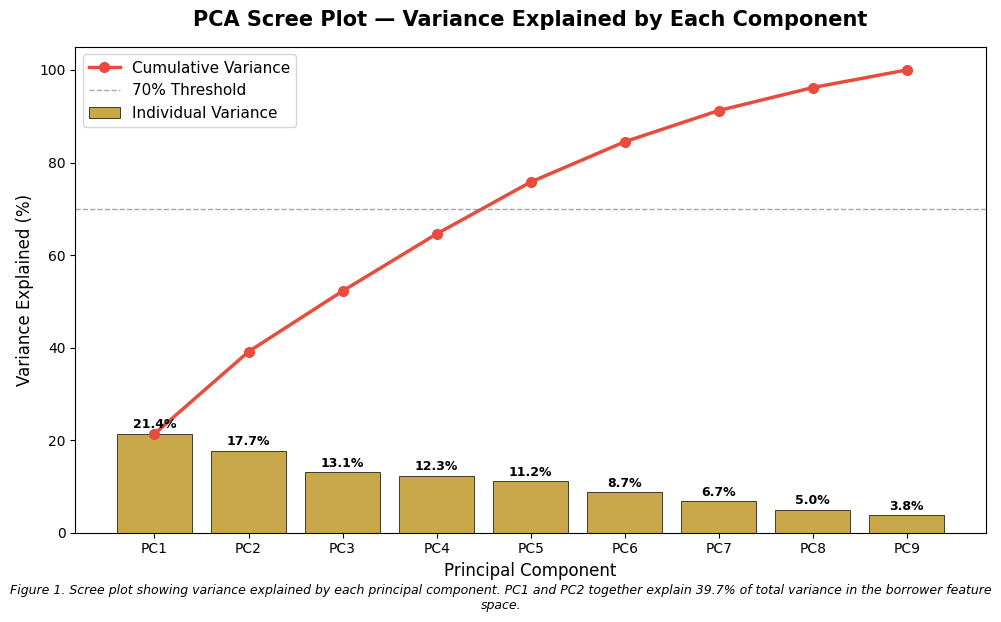

In [32]:
# PCA Visualization 1 — Scree Plot
plt.figure(figsize=(10, 6))

variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)
pc_labels = [f'PC{i+1}' for i in range(len(variance_ratio))]

plt.bar(pc_labels, variance_ratio * 100, color='#c8a84b',
        edgecolor='black', linewidth=0.5, label='Individual Variance')
plt.plot(pc_labels, cumulative_variance * 100,
         color='#e74c3c', marker='o', linewidth=2.5,
         markersize=7, label='Cumulative Variance')

for i, (var, cum) in enumerate(zip(variance_ratio, cumulative_variance)):
    plt.text(i, var * 100 + 0.5, f'{var*100:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.axhline(y=70, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='70% Threshold')
plt.title('PCA Scree Plot — Variance Explained by Each Component',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Variance Explained (%)', fontsize=12)
plt.legend(fontsize=11)
plt.figtext(0.5, -0.02,
            'Figure 1. Scree plot showing variance explained by each principal component. '
            'PC1 and PC2 together explain 39.7% of total variance in the borrower feature space.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

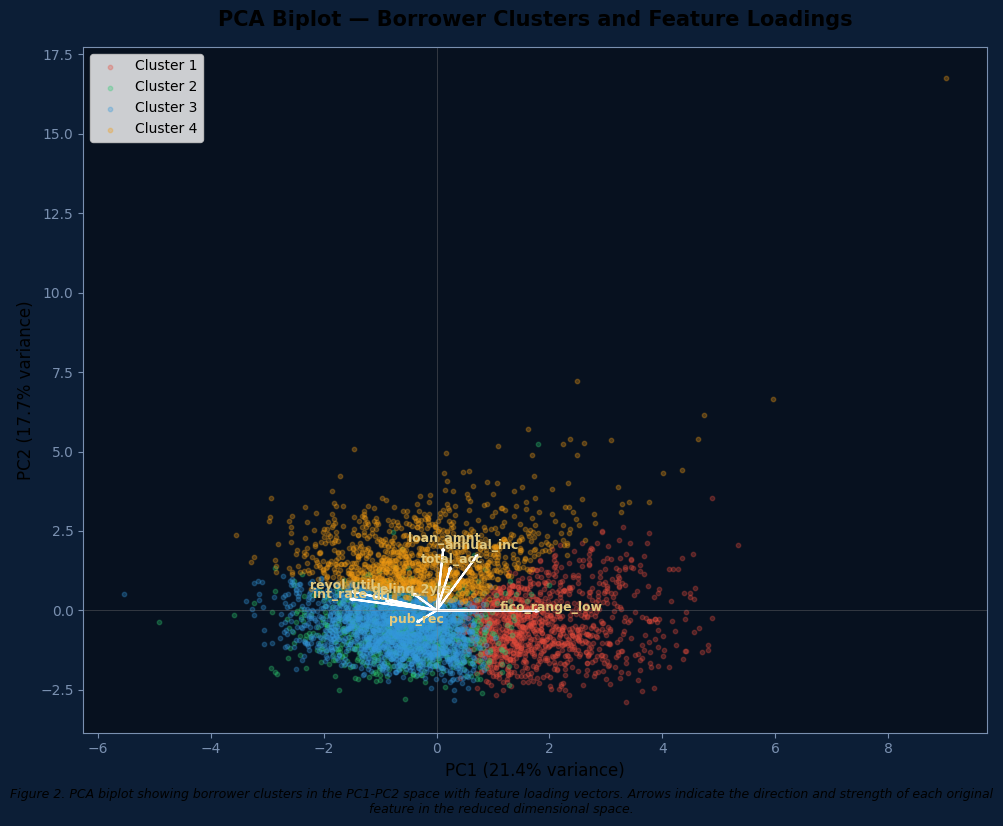

In [33]:
# PCA Visualization 2 — Biplot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
for i in range(4):
    mask = labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[i], alpha=0.3, s=10, label=f'Cluster {i+1}')

feature_names = cluster_features
loadings = pca.components_.T
scale = 3

for i, feature in enumerate(feature_names):
    ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
             head_width=0.05, head_length=0.05,
             fc='white', ec='white', linewidth=1.5)
    ax.text(loadings[i, 0]*scale*1.15, loadings[i, 1]*scale*1.15,
            feature, fontsize=9, color='#e2c97e', fontweight='bold', ha='center')

ax.set_xlabel(f'PC1 ({variance_ratio[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({variance_ratio[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Biplot — Borrower Clusters and Feature Loadings',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_facecolor('#07111f')
fig.patch.set_facecolor('#0c1e36')
ax.tick_params(colors='#7a90b0')
ax.spines['bottom'].set_color('#7a90b0')
ax.spines['left'].set_color('#7a90b0')
ax.spines['top'].set_color('#7a90b0')
ax.spines['right'].set_color('#7a90b0')

plt.figtext(0.5, -0.02,
            'Figure 2. PCA biplot showing borrower clusters in the PC1-PC2 space with feature loading vectors. '
            'Arrows indicate the direction and strength of each original feature in the reduced dimensional space.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

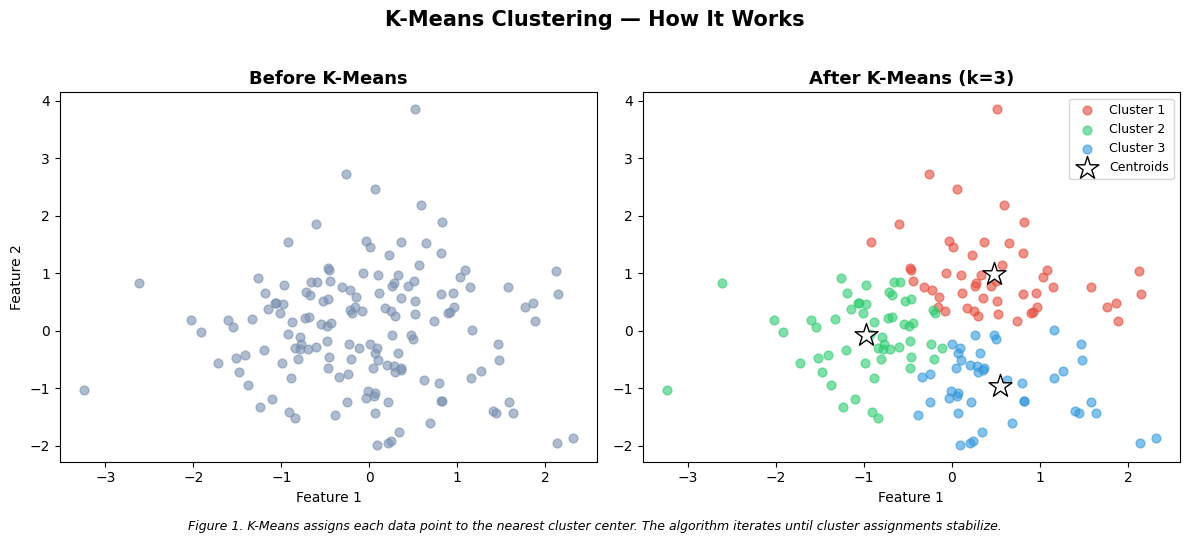

In [34]:
# Clustering Overview Image 1 — K-Means concept diagram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

np.random.seed(42)
X_demo = np.random.randn(150, 2)
axes[0].scatter(X_demo[:, 0], X_demo[:, 1], color='#7a90b0', alpha=0.6, s=40)
axes[0].set_title('Before K-Means', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

from sklearn.cluster import KMeans
km_demo = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_demo = km_demo.fit_predict(X_demo)
colors_demo = ['#e74c3c', '#2ecc71', '#3498db']
for i in range(3):
    axes[1].scatter(X_demo[labels_demo==i, 0], X_demo[labels_demo==i, 1],
                    c=colors_demo[i], alpha=0.6, s=40, label=f'Cluster {i+1}')
axes[1].scatter(km_demo.cluster_centers_[:, 0], km_demo.cluster_centers_[:, 1],
                c='white', marker='*', s=300, edgecolors='black', linewidth=1, zorder=5, label='Centroids')
axes[1].set_title('After K-Means (k=3)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature 1'); axes[1].legend(fontsize=9)

plt.suptitle('K-Means Clustering — How It Works', fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02, 'Figure 1. K-Means assigns each data point to the nearest cluster center. The algorithm iterates until cluster assignments stabilize.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('clustering_overview1.png', dpi=150, bbox_inches='tight')
plt.show()

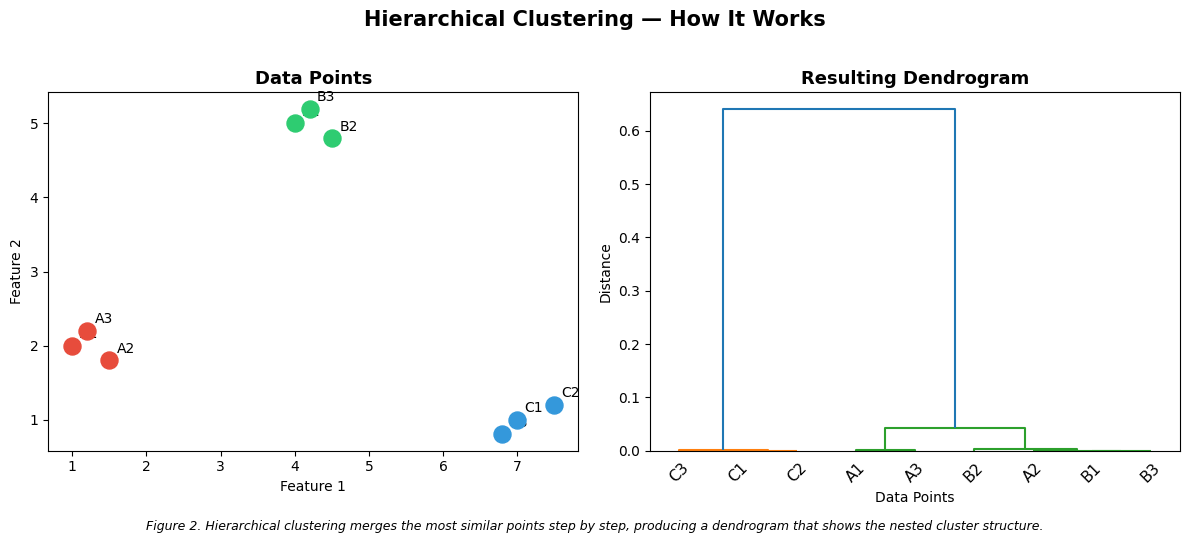

In [35]:
# Clustering Overview Image 2 — Hierarchical clustering concept
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

np.random.seed(42)
X_hier = np.array([
    [1, 2], [1.5, 1.8], [1.2, 2.2],
    [4, 5], [4.5, 4.8], [4.2, 5.2],
    [7, 1], [7.5, 1.2], [6.8, 0.8]
])
labels_hier = ['A1','A2','A3','B1','B2','B3','C1','C2','C3']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_h = ['#e74c3c']*3 + ['#2ecc71']*3 + ['#3498db']*3
for i, (x, label) in enumerate(zip(X_hier, labels_hier)):
    axes[0].scatter(x[0], x[1], c=colors_h[i], s=150, zorder=5)
    axes[0].annotate(label, (x[0]+0.1, x[1]+0.1), fontsize=10)
axes[0].set_title('Data Points', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

dist = pdist(X_hier, metric='cosine')
Z_hier = linkage(dist, method='ward')
dendrogram(Z_hier, labels=labels_hier, ax=axes[1],
           color_threshold=0.8*max(Z_hier[:,2]),
           leaf_rotation=45, leaf_font_size=11)
axes[1].set_title('Resulting Dendrogram', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Data Points'); axes[1].set_ylabel('Distance')

plt.suptitle('Hierarchical Clustering — How It Works', fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02,
            'Figure 2. Hierarchical clustering merges the most similar points step by step, '
            'producing a dendrogram that shows the nested cluster structure.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('clustering_overview2.png', dpi=150, bbox_inches='tight')
plt.show()

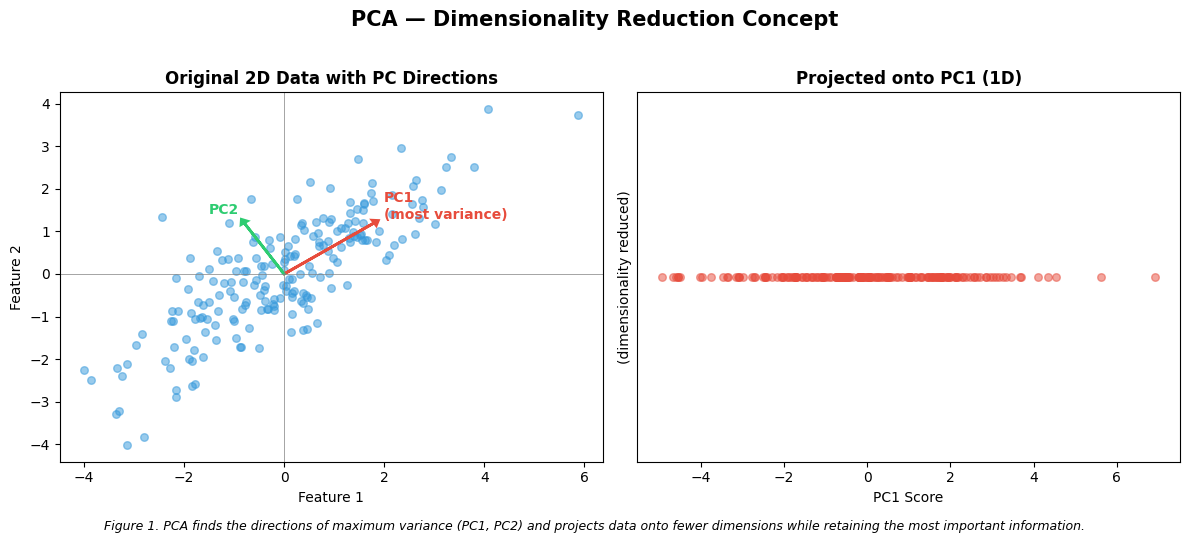

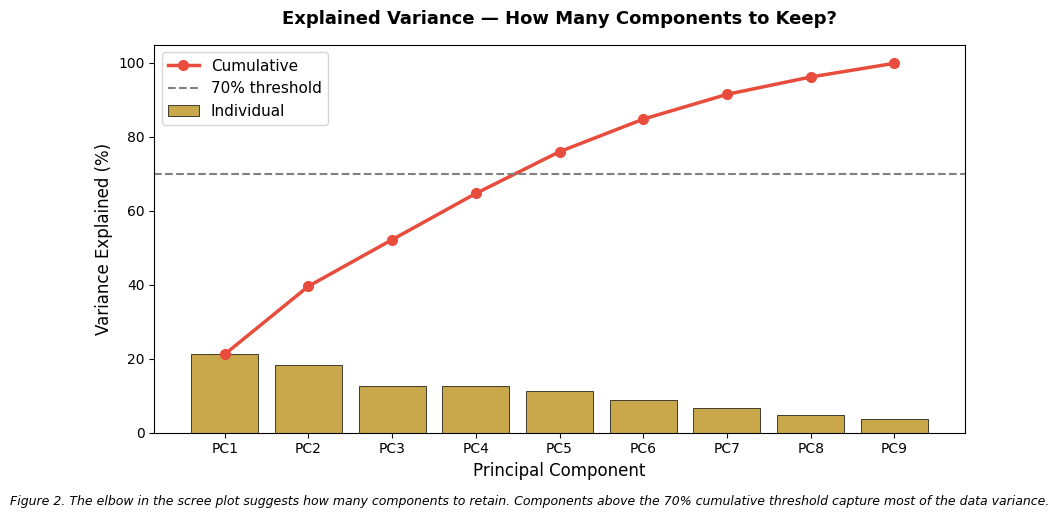

In [36]:
# PCA Overview Image 1 — PCA concept (high dim to low dim)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]
X_pca_demo = np.random.multivariate_normal(mean, cov, 200)

axes[0].scatter(X_pca_demo[:, 0], X_pca_demo[:, 1], alpha=0.5, color='#3498db', s=30)
axes[0].arrow(0, 0, 1.8, 1.2, head_width=0.15, head_length=0.1, fc='#e74c3c', ec='#e74c3c', linewidth=2)
axes[0].arrow(0, 0, -0.8, 1.2, head_width=0.15, head_length=0.1, fc='#2ecc71', ec='#2ecc71', linewidth=2)
axes[0].text(2.0, 1.3, 'PC1\n(most variance)', color='#e74c3c', fontsize=10, fontweight='bold')
axes[0].text(-1.5, 1.4, 'PC2', color='#2ecc71', fontsize=10, fontweight='bold')
axes[0].set_title('Original 2D Data with PC Directions', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].axhline(0, color='gray', linewidth=0.5); axes[0].axvline(0, color='gray', linewidth=0.5)

from sklearn.decomposition import PCA as PCA_demo
pca_demo = PCA_demo(n_components=1)
X_proj = pca_demo.fit_transform(X_pca_demo)
axes[1].scatter(X_proj[:, 0], np.zeros_like(X_proj[:, 0]), alpha=0.5, color='#e74c3c', s=30)
axes[1].set_title('Projected onto PC1 (1D)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1 Score'); axes[1].set_yticks([])
axes[1].set_ylabel('(dimensionality reduced)')

plt.suptitle('PCA — Dimensionality Reduction Concept', fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02,
            'Figure 1. PCA finds the directions of maximum variance (PC1, PC2) and projects '
            'data onto fewer dimensions while retaining the most important information.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('pca_overview1.png', dpi=150, bbox_inches='tight')
plt.show()

# PCA Overview Image 2 — Explained variance concept
fig, ax = plt.subplots(figsize=(9, 5))
components = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9']
variances = [21.2, 18.4, 12.6, 12.5, 11.3, 8.8, 6.7, 4.7, 3.7]
cumulative = np.cumsum(variances)

ax.bar(components, variances, color='#c8a84b', edgecolor='black', linewidth=0.5, label='Individual')
ax.plot(components, cumulative, color='#e74c3c', marker='o', linewidth=2.5, markersize=7, label='Cumulative')
ax.axhline(y=70, color='gray', linestyle='--', linewidth=1.5, label='70% threshold')
ax.set_title('Explained Variance — How Many Components to Keep?', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Variance Explained (%)', fontsize=12)
ax.legend(fontsize=11)
plt.figtext(0.5, -0.02,
            'Figure 2. The elbow in the scree plot suggests how many components to retain. '
            'Components above the 70% cumulative threshold capture most of the data variance.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('pca_overview2.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# PCA data sample - screenshot this output
print("PCA INPUT DATA — First 5 rows (Standardized):")
import pandas as pd
pca_sample = pd.DataFrame(X_scaled[:5], columns=cluster_features)
print(pca_sample.round(3).to_string())

PCA INPUT DATA — First 5 rows (Standardized):
   loan_amnt  int_rate  annual_inc    dti  fico_range_low  revol_util  delinq_2yrs  total_acc  pub_rec
0      1.070    -0.658       0.470  0.027          -0.805       0.223       -0.362     -0.497    3.170
1      1.070     2.225      -0.321  0.865          -0.494       0.405       -0.362     -0.665   -0.368
2     -0.745    -1.074       0.316 -1.790           0.128      -0.961       -0.362     -0.665   -0.368
3     -1.313     1.345      -0.495 -1.856          -0.960      -1.465       -0.362     -1.590   -0.368
4      2.001    -0.041       0.856  0.670          -0.494       1.016        1.814      0.847   -0.368


In [38]:
print("RAW DATA (Before Scaling) — First 5 rows:")
print(df_cluster[cluster_features].head().to_string())

RAW DATA (Before Scaling) — First 5 rows:
         loan_amnt  int_rate  annual_inc    dti  fico_range_low  revol_util  delinq_2yrs  total_acc  pub_rec
98720      24000.0      9.99    100000.0  18.36           670.0        57.4          0.0       19.0      2.0
546509     24000.0     23.99     59000.0  25.83           680.0        61.8          0.0       17.0      0.0
420550      8000.0      7.97     92000.0   2.16           700.0        28.7          0.0       17.0      0.0
1085081     3000.0     19.72     50000.0   1.57           665.0        16.5          0.0        6.0      0.0
753659     32200.0     12.99    120000.0  24.09           680.0        76.6          2.0       35.0      0.0


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
            'fico_range_low', 'revol_util', 'delinq_2yrs',
            'total_acc', 'pub_rec']

X = df_loans[features].dropna()
y = df_loans.loc[X.index, 'default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Training default rate: {y_train.mean():.4f}")
print(f"Testing default rate: {y_test.mean():.4f}")

print("\nTRAINING SET — First 5 rows:")
print(pd.concat([X_train.head(), y_train.head()], axis=1).to_string())

print("\nTESTING SET — First 5 rows:")
print(pd.concat([X_test.head(), y_test.head()], axis=1).to_string())

Training set: (1022349, 9)
Testing set: (255588, 9)
Training default rate: 0.1977
Testing default rate: 0.1977

TRAINING SET — First 5 rows:
        loan_amnt  int_rate  annual_inc    dti  fico_range_low  revol_util  delinq_2yrs  total_acc  pub_rec  default
770791    24500.0     24.08    105000.0  11.75           670.0        61.8          0.0       31.0      0.0        1
761032    18000.0     13.98    100000.0  18.64           670.0        67.8          0.0       24.0      1.0        1
487326     4525.0     12.99     45000.0   5.65           675.0        43.0          4.0       24.0      1.0        0
956118     4000.0      9.45     24996.0  11.38           720.0        24.0          0.0       16.0      0.0        0
289888    10000.0      8.18     65000.0  23.57           775.0        16.2          0.0       59.0      0.0        0

TESTING SET — First 5 rows:
         loan_amnt  int_rate  annual_inc    dti  fico_range_low  revol_util  delinq_2yrs  total_acc  pub_rec  default
61054     

Accuracy: 0.7945

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88    205061
           1       0.43      0.13      0.20     50527

    accuracy                           0.79    255588
   macro avg       0.63      0.54      0.54    255588
weighted avg       0.74      0.79      0.75    255588



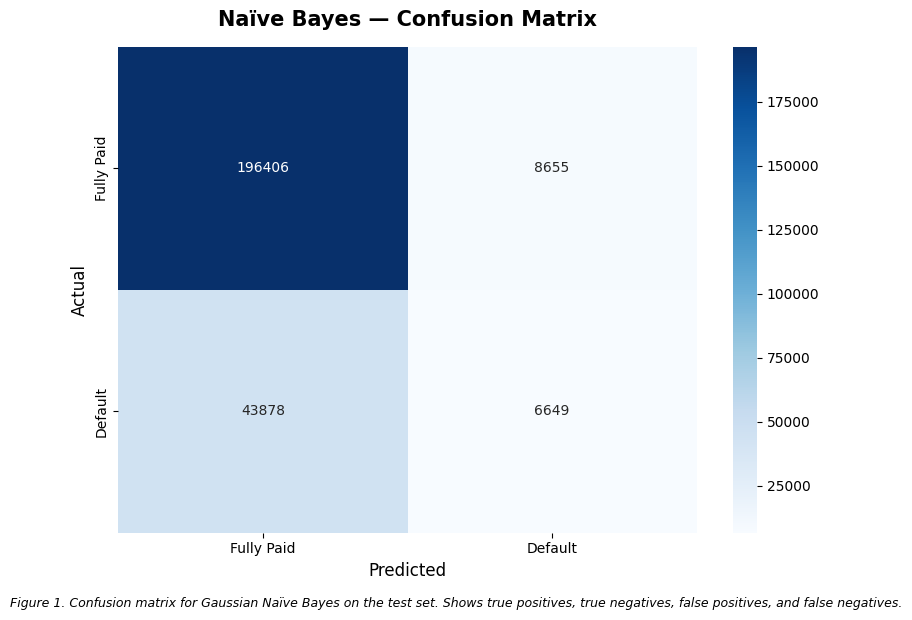

In [40]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fully Paid', 'Default'],
            yticklabels=['Fully Paid', 'Default'])
plt.title('Naïve Bayes — Confusion Matrix', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 1. Confusion matrix for Gaussian Naïve Bayes on the test set. '
            'Shows true positives, true negatives, false positives, and false negatives.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

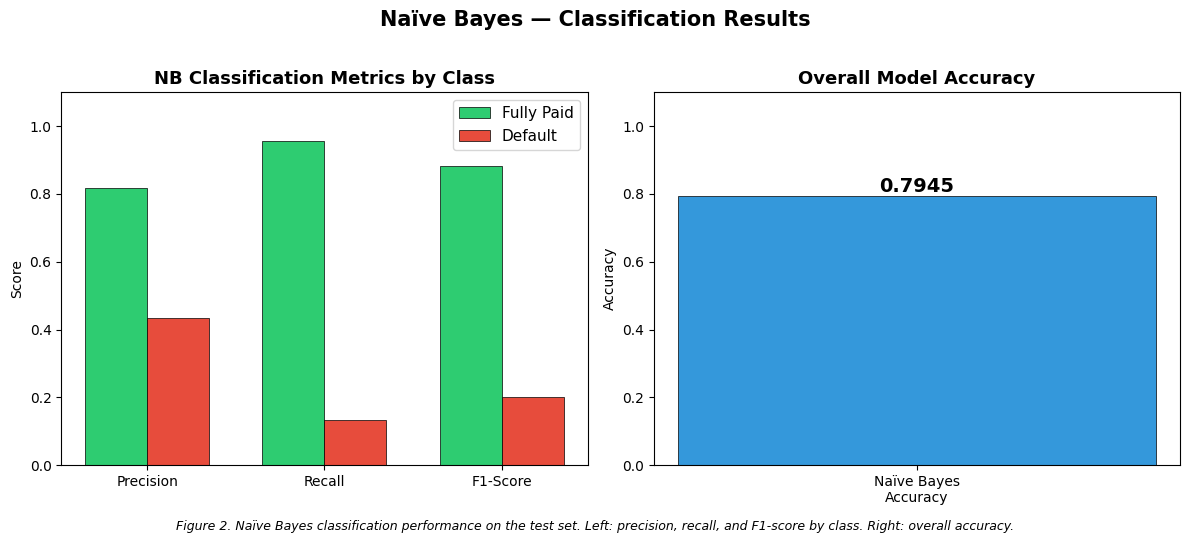

Accuracy: 0.7945


In [41]:
# NB Results visualization
report = classification_report(y_test, y_pred, output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
fully_paid = [report['0'][m] for m in metrics]
default = [report['1'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: precision/recall/f1
axes[0].bar(x - width/2, fully_paid, width, label='Fully Paid', color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[0].bar(x + width/2, default, width, label='Default', color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Precision', 'Recall', 'F1-Score'])
axes[0].set_ylim(0, 1.1)
axes[0].set_title('NB Classification Metrics by Class', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_ylabel('Score')

# Right: accuracy bar
accuracy = accuracy_score(y_test, y_pred)
axes[1].bar(['Naïve Bayes\nAccuracy'], [accuracy], color='#3498db', edgecolor='black', linewidth=0.5, width=0.4)
axes[1].text(0, accuracy + 0.01, f'{accuracy:.4f}', ha='center', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Overall Model Accuracy', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy')

plt.suptitle('Naïve Bayes — Classification Results', fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02,
            'Figure 2. Naïve Bayes classification performance on the test set. '
            'Left: precision, recall, and F1-score by class. Right: overall accuracy.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('nb_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Accuracy: {accuracy:.4f}")

Tree 1 (depth=3) Accuracy: 0.8023
Tree 2 (depth=5) Accuracy: 0.8023
Tree 3 (depth=10) Accuracy: 0.8022


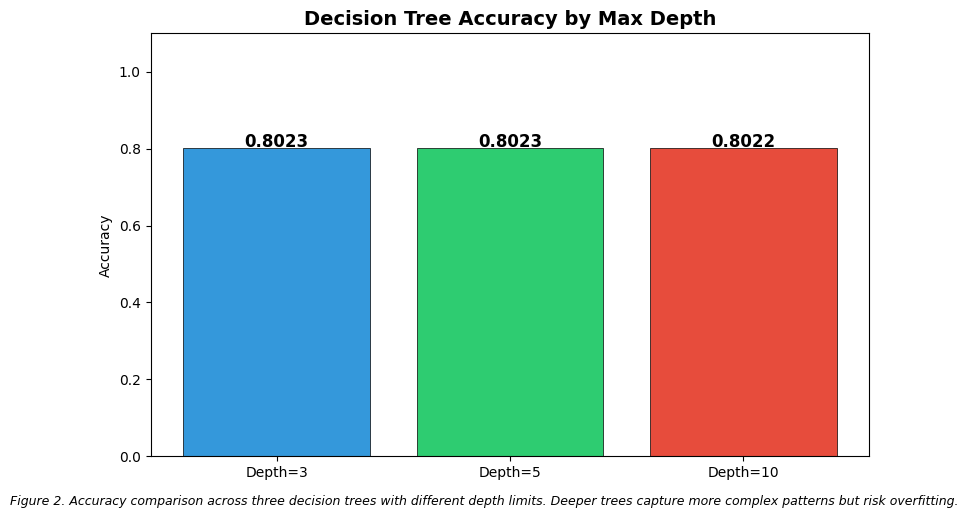

In [42]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

dt1 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt1.fit(X_train, y_train)
acc1 = accuracy_score(y_test, dt1.predict(X_test))
print(f"Tree 1 (depth=3) Accuracy: {acc1:.4f}")

dt2 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt2.fit(X_train, y_train)
acc2 = accuracy_score(y_test, dt2.predict(X_test))
print(f"Tree 2 (depth=5) Accuracy: {acc2:.4f}")

dt3 = DecisionTreeClassifier(max_depth=10, random_state=42)
dt3.fit(X_train, y_train)
acc3 = accuracy_score(y_test, dt3.predict(X_test))
print(f"Tree 3 (depth=10) Accuracy: {acc3:.4f}")

plt.figure(figsize=(8, 5))
accs = [acc1, acc2, acc3]
labels = ['Depth=3', 'Depth=5', 'Depth=10']
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar(labels, accs, color=colors, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.title('Decision Tree Accuracy by Max Depth', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.figtext(0.5, -0.02,
            'Figure 2. Accuracy comparison across three decision trees with different depth limits. '
            'Deeper trees capture more complex patterns but risk overfitting.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('dt_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

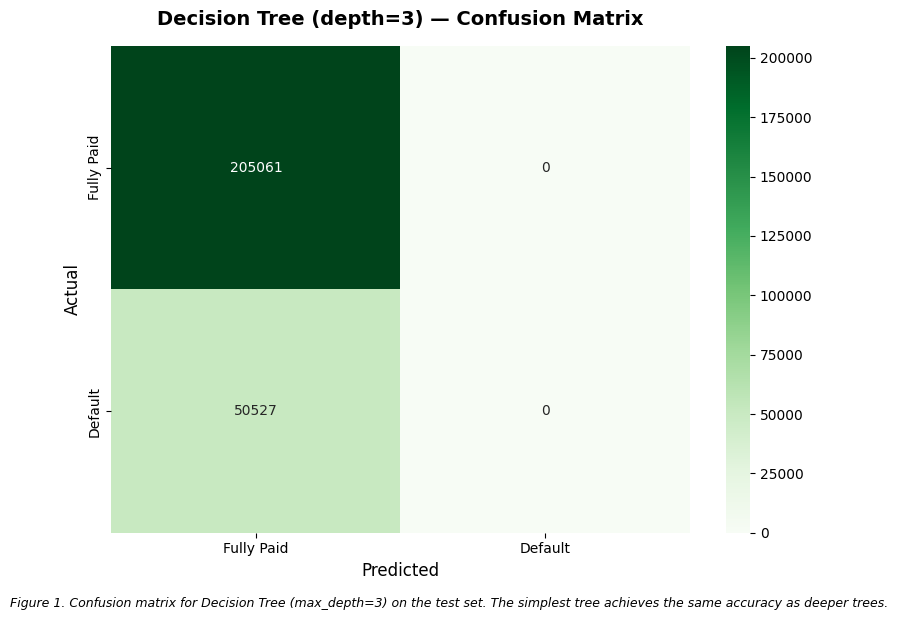

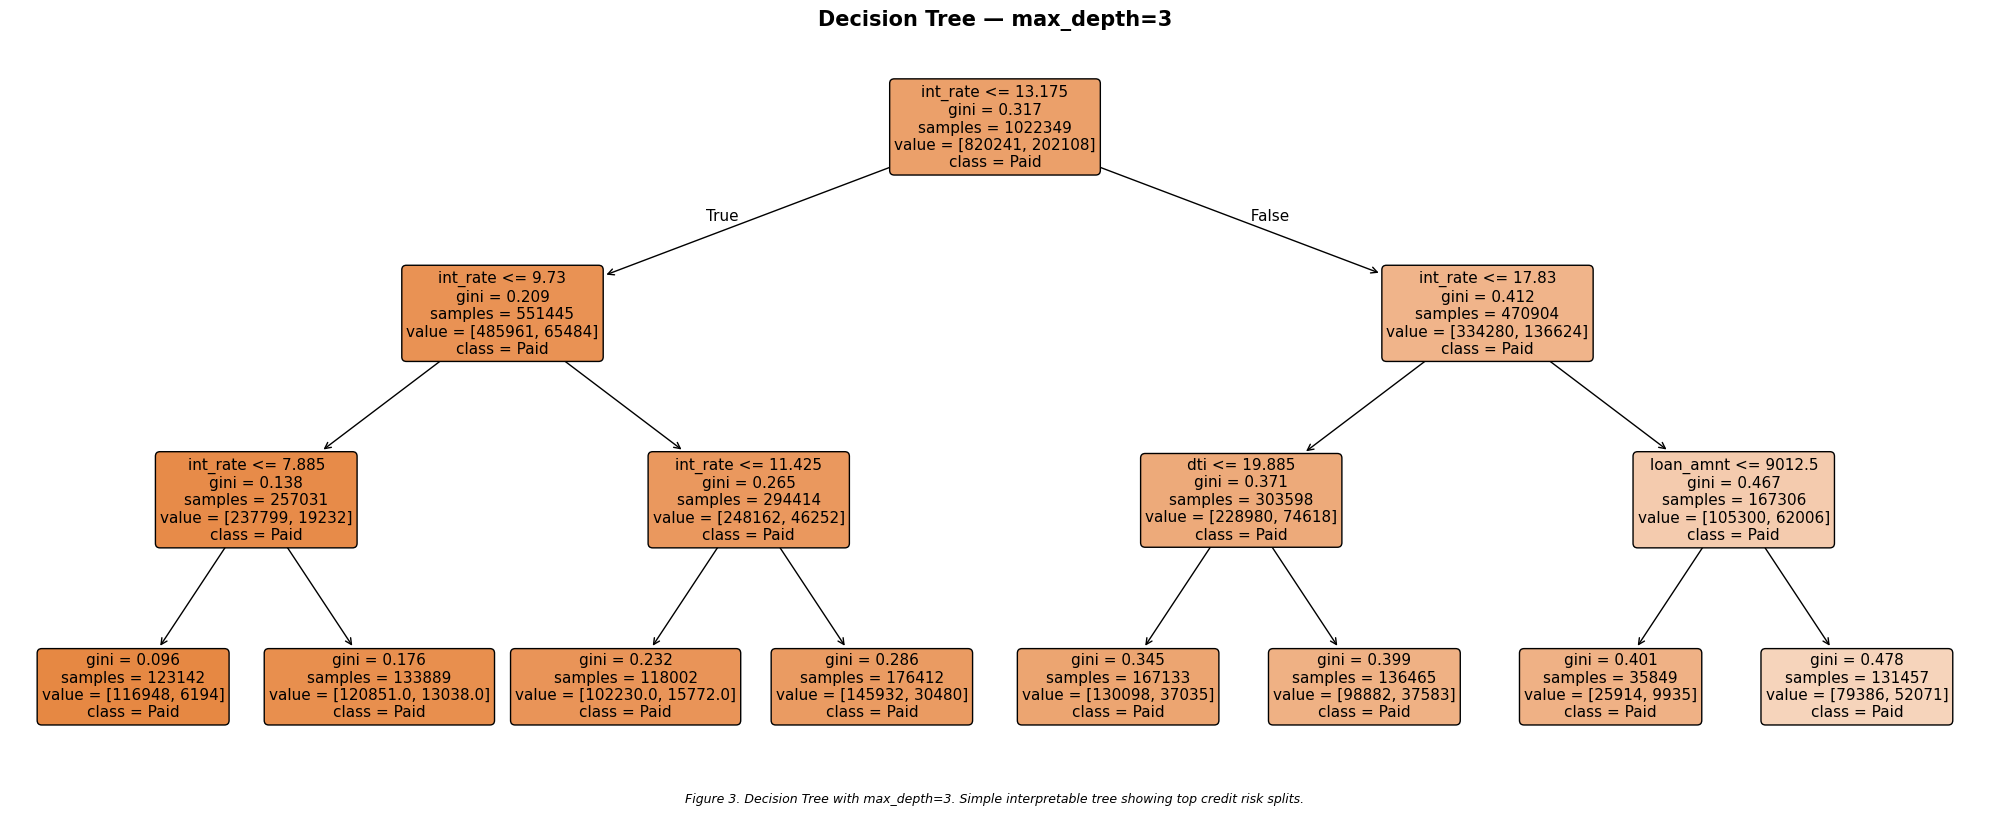

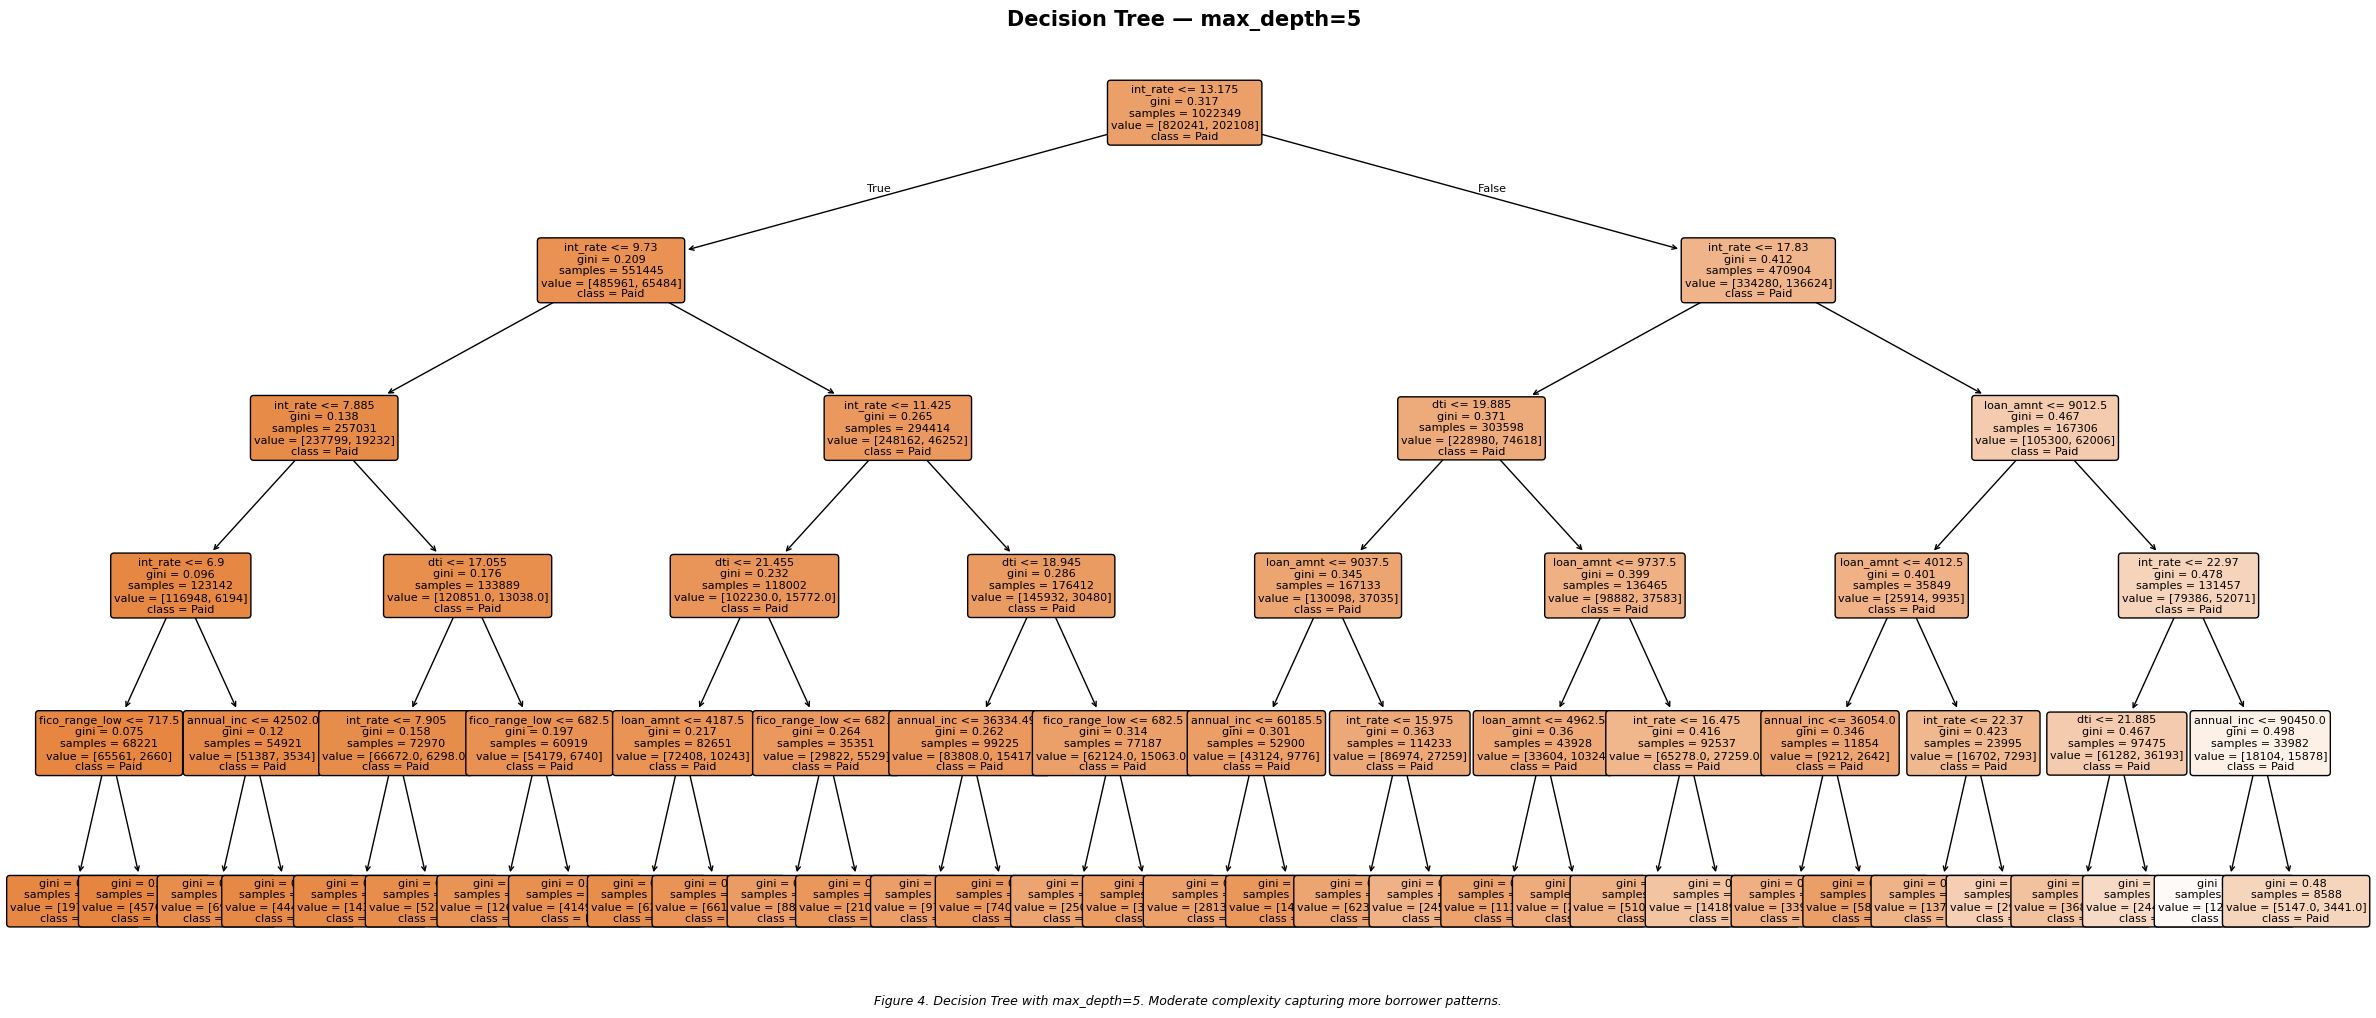

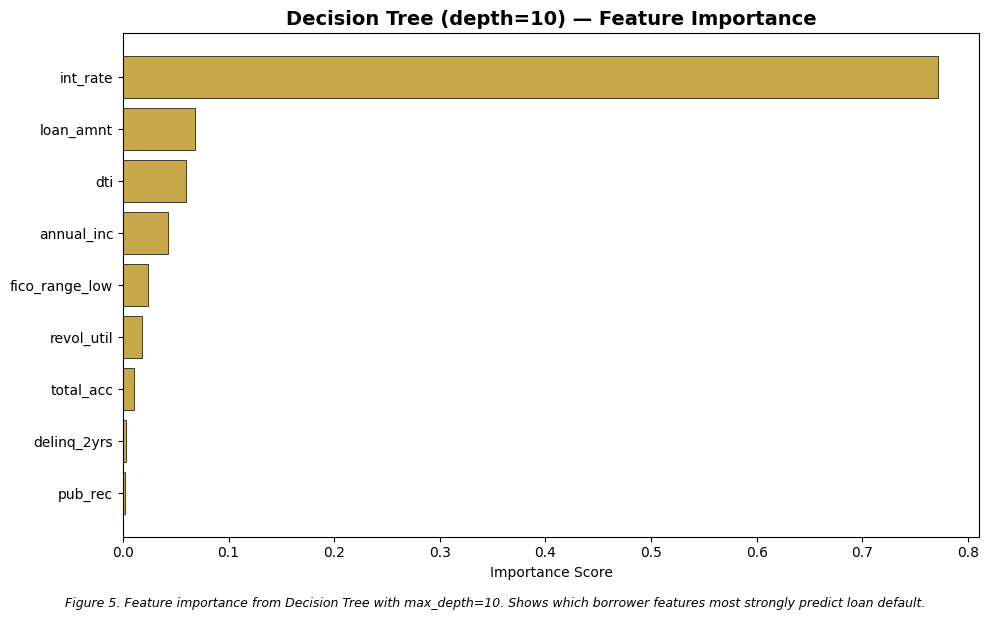

In [43]:
plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, dt1.predict(X_test))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fully Paid', 'Default'],
            yticklabels=['Fully Paid', 'Default'])
plt.title('Decision Tree (depth=3) — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 1. Confusion matrix for Decision Tree (max_depth=3) on the test set. '
            'The simplest tree achieves the same accuracy as deeper trees.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(20, 8))
plot_tree(dt1, feature_names=features, class_names=['Paid','Default'],
          filled=True, rounded=True, fontsize=11)
plt.title('Decision Tree — max_depth=3', fontsize=15, fontweight='bold')
plt.figtext(0.5, -0.01,
            'Figure 3. Decision Tree with max_depth=3. Simple interpretable tree showing top credit risk splits.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('dt_tree1.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(24, 10))
plot_tree(dt2, feature_names=features, class_names=['Paid','Default'],
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree — max_depth=5', fontsize=15, fontweight='bold')
plt.figtext(0.5, -0.01,
            'Figure 4. Decision Tree with max_depth=5. Moderate complexity capturing more borrower patterns.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('dt_tree2.png', dpi=150, bbox_inches='tight')
plt.show()

importances = dt3.feature_importances_
plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(importances)
plt.barh([features[i] for i in sorted_idx], importances[sorted_idx],
         color='#c8a84b', edgecolor='black', linewidth=0.5)
plt.title('Decision Tree (depth=10) — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.figtext(0.5, -0.02,
            'Figure 5. Feature importance from Decision Tree with max_depth=10. '
            'Shows which borrower features most strongly predict loan default.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('dt_tree3.png', dpi=150, bbox_inches='tight')
plt.show()

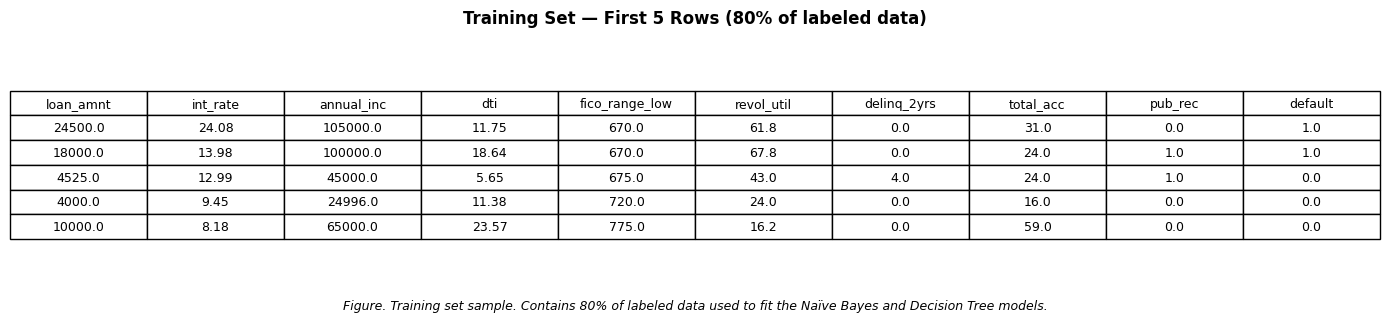

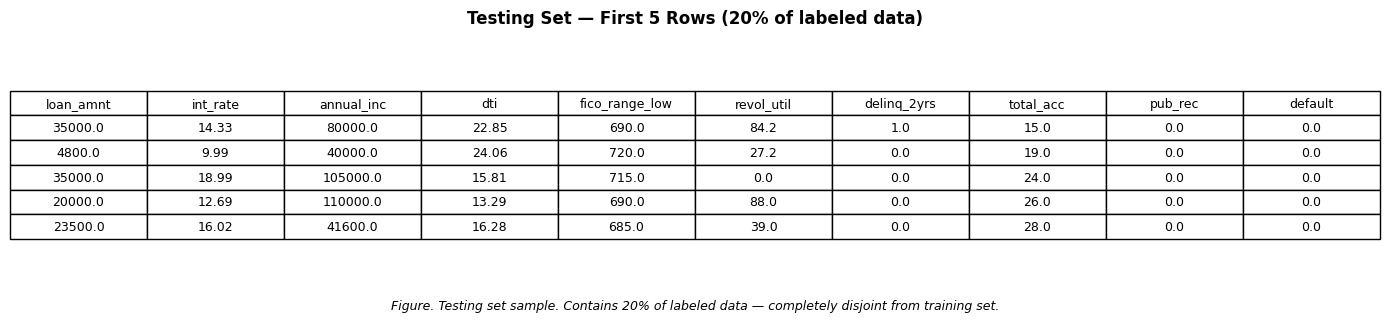

In [44]:
train_preview = pd.concat([X_train.head(), y_train.head()], axis=1)
test_preview = pd.concat([X_test.head(), y_test.head()], axis=1)

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
table = ax.table(cellText=train_preview.round(2).values,
                 colLabels=train_preview.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
plt.title('Training Set — First 5 Rows (80% of labeled data)',
          fontsize=12, fontweight='bold', pad=20)
plt.figtext(0.5, -0.05,
            'Figure. Training set sample. Contains 80% of labeled data used to fit the Naïve Bayes and Decision Tree models.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('nb_train_sample.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
table = ax.table(cellText=test_preview.round(2).values,
                 colLabels=test_preview.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
plt.title('Testing Set — First 5 Rows (20% of labeled data)',
          fontsize=12, fontweight='bold', pad=20)
plt.figtext(0.5, -0.05,
            'Figure. Testing set sample. Contains 20% of labeled data — completely disjoint from training set.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('nb_test_sample.png', dpi=150, bbox_inches='tight')
plt.show()

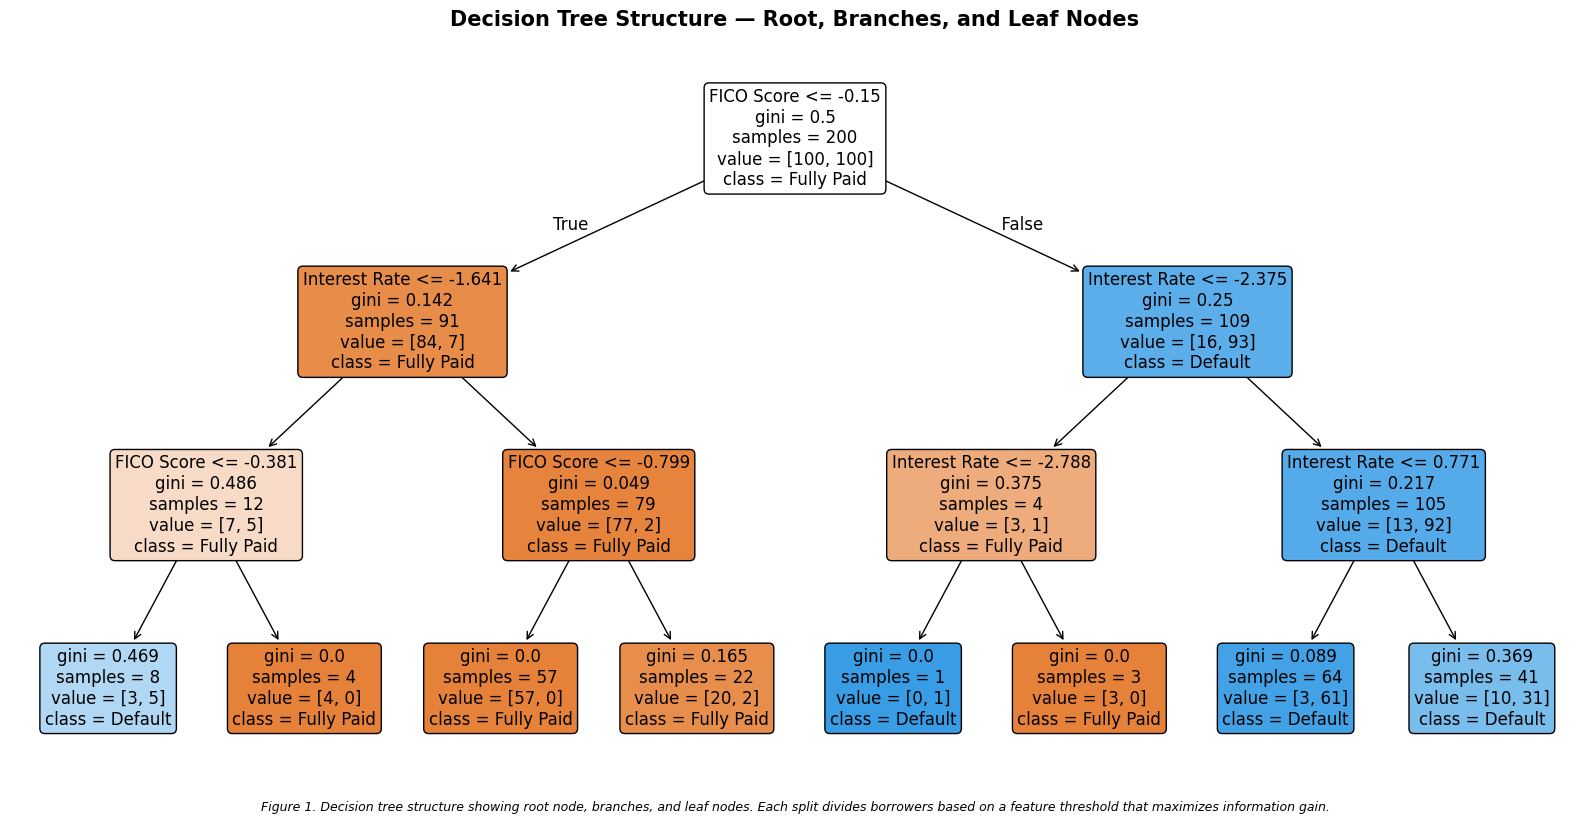

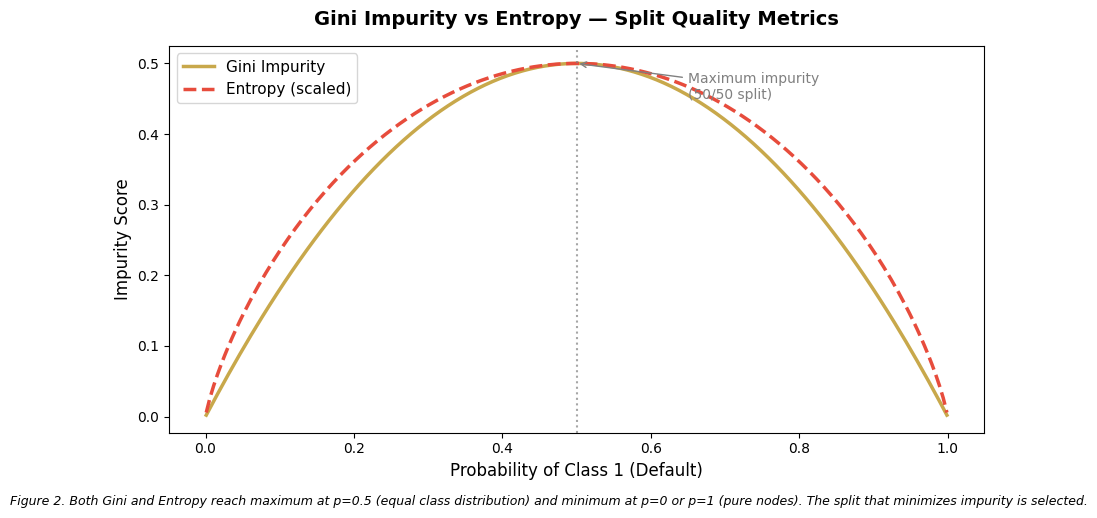

In [45]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_classification
X_demo, y_demo = make_classification(n_samples=200, n_features=2,
                                      n_informative=2, n_redundant=0,
                                      random_state=42)
dt_demo = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_demo.fit(X_demo, y_demo)

plt.figure(figsize=(16, 8))
plot_tree(dt_demo,
          feature_names=['FICO Score', 'Interest Rate'],
          class_names=['Fully Paid', 'Default'],
          filled=True, rounded=True, fontsize=12)
plt.title('Decision Tree Structure — Root, Branches, and Leaf Nodes',
          fontsize=15, fontweight='bold', pad=15)
plt.figtext(0.5, -0.02,
            'Figure 1. Decision tree structure showing root node, branches, and leaf nodes. '
            'Each split divides borrowers based on a feature threshold that maximizes information gain.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('dt_overview1.png', dpi=150, bbox_inches='tight')
plt.show()

p = np.linspace(0.001, 0.999, 200)
gini = 2 * p * (1 - p)
entropy = -p * np.log2(p) - (1-p) * np.log2(1-p)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p, gini, color='#c8a84b', linewidth=2.5, label='Gini Impurity')
ax.plot(p, entropy/2, color='#e74c3c', linewidth=2.5,
        linestyle='--', label='Entropy (scaled)')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Probability of Class 1 (Default)', fontsize=12)
ax.set_ylabel('Impurity Score', fontsize=12)
ax.set_title('Gini Impurity vs Entropy — Split Quality Metrics',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.annotate('Maximum impurity\n(50/50 split)', xy=(0.5, 0.5),
            xytext=(0.65, 0.45), fontsize=10, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))
plt.figtext(0.5, -0.02,
            'Figure 2. Both Gini and Entropy reach maximum at p=0.5 (equal class distribution) '
            'and minimum at p=0 or p=1 (pure nodes). The split that minimizes impurity is selected.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('dt_overview2.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Full dataset sample before splitting
print("FULL LABELED DATASET — First 5 rows (before train/test split):")
full_sample = pd.concat([X.head(), y.head()], axis=1)
print(full_sample.to_string())

FULL LABELED DATASET — First 5 rows (before train/test split):
   loan_amnt  int_rate  annual_inc    dti  fico_range_low  revol_util  delinq_2yrs  total_acc  pub_rec  default
0     3600.0     13.99     55000.0   5.91           675.0        29.7          0.0       13.0      0.0        0
1    24700.0     11.99     65000.0  16.06           715.0        19.2          1.0       38.0      0.0        0
2    20000.0     10.78     63000.0  10.78           695.0        56.2          0.0       18.0      0.0        0
3    10400.0     22.45    104433.0  25.37           695.0        64.5          1.0       35.0      0.0        0
4    11950.0     13.44     34000.0  10.20           690.0        68.4          0.0        6.0      0.0        0


Tree 3 (depth=7) Accuracy: 0.8029


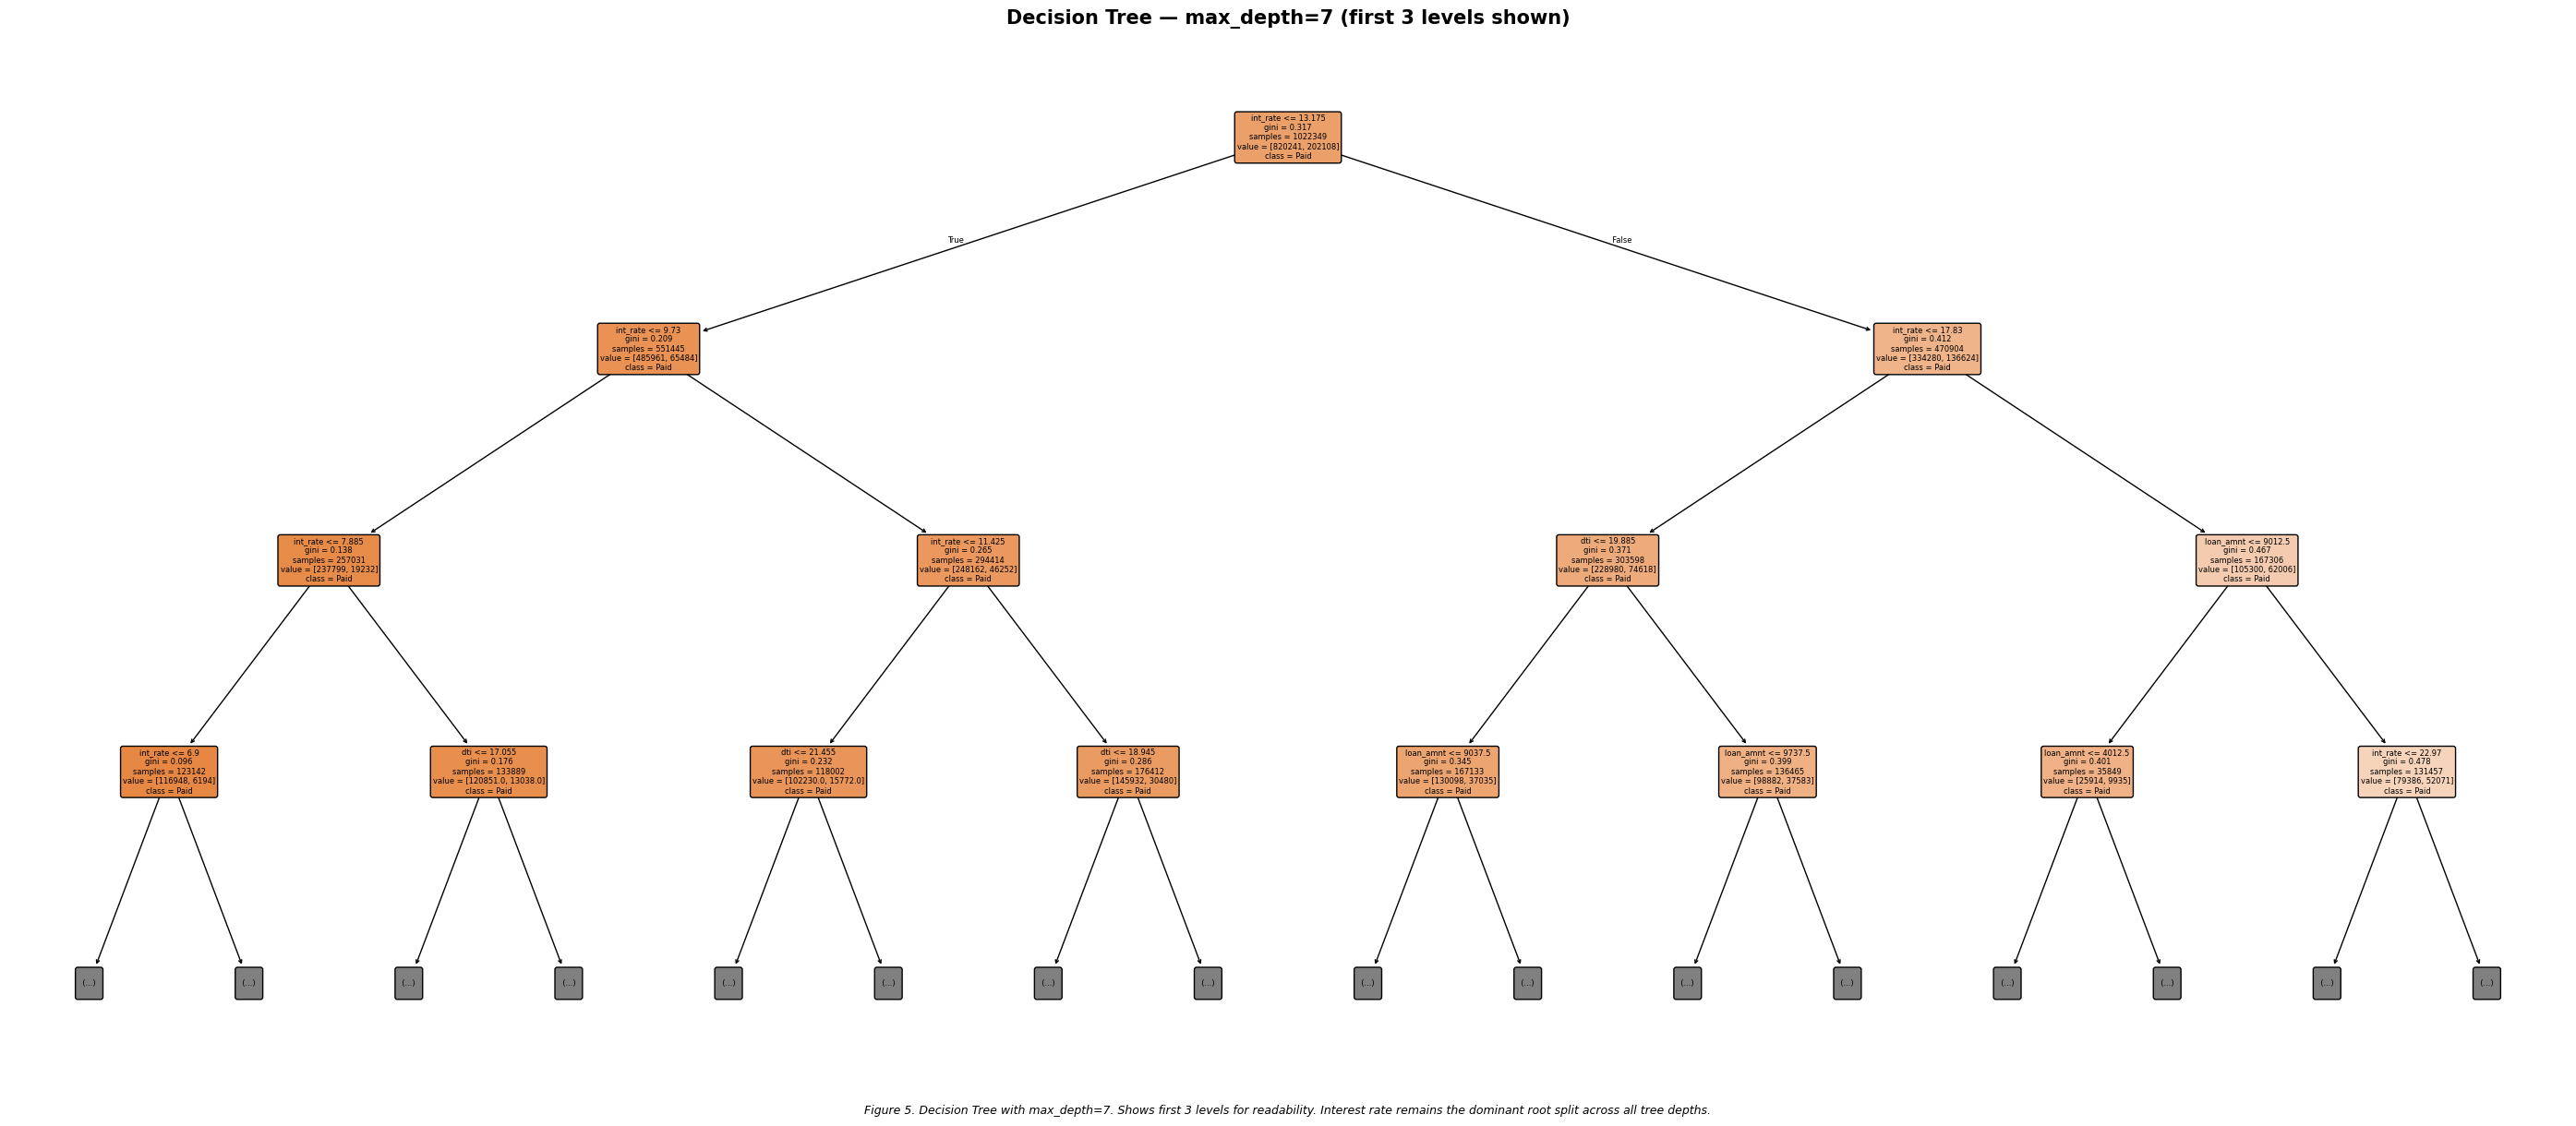

In [47]:
# Tree 3 — actual tree visualization with max_depth=7
dt3_vis = DecisionTreeClassifier(max_depth=7, random_state=42)
dt3_vis.fit(X_train, y_train)
acc3_vis = accuracy_score(y_test, dt3_vis.predict(X_test))
print(f"Tree 3 (depth=7) Accuracy: {acc3_vis:.4f}")

plt.figure(figsize=(28, 12))
plot_tree(dt3_vis, feature_names=features, class_names=['Paid','Default'],
          filled=True, rounded=True, fontsize=6,
          max_depth=3)
plt.title('Decision Tree — max_depth=7 (first 3 levels shown)',
          fontsize=15, fontweight='bold')
plt.figtext(0.5, -0.01,
            'Figure 5. Decision Tree with max_depth=7. Shows first 3 levels for readability. '
            'Interest rate remains the dominant root split across all tree depths.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('dt_tree3.png', dpi=150, bbox_inches='tight')
plt.show()

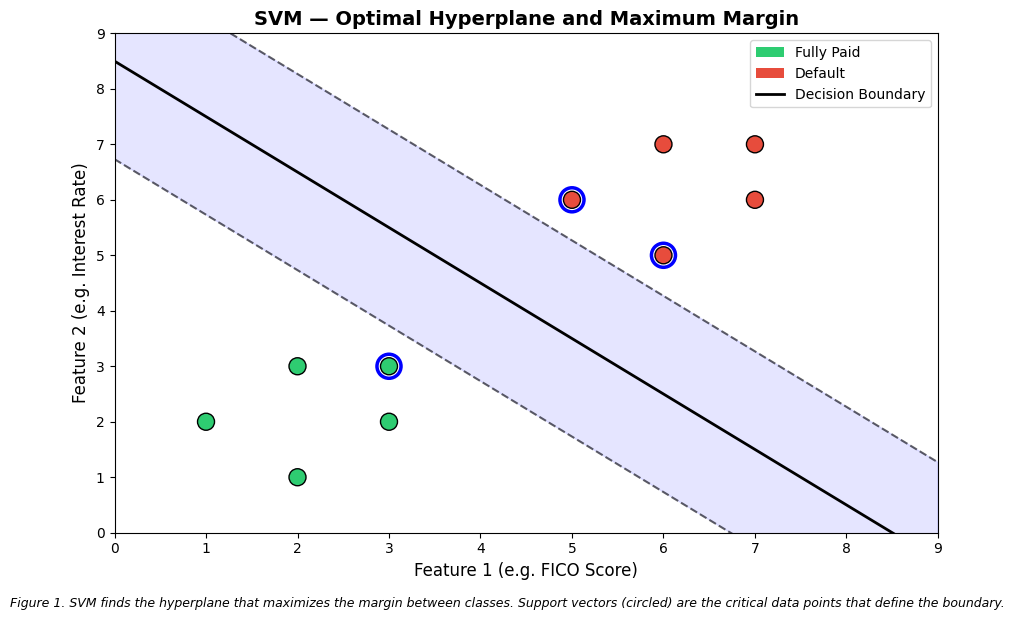

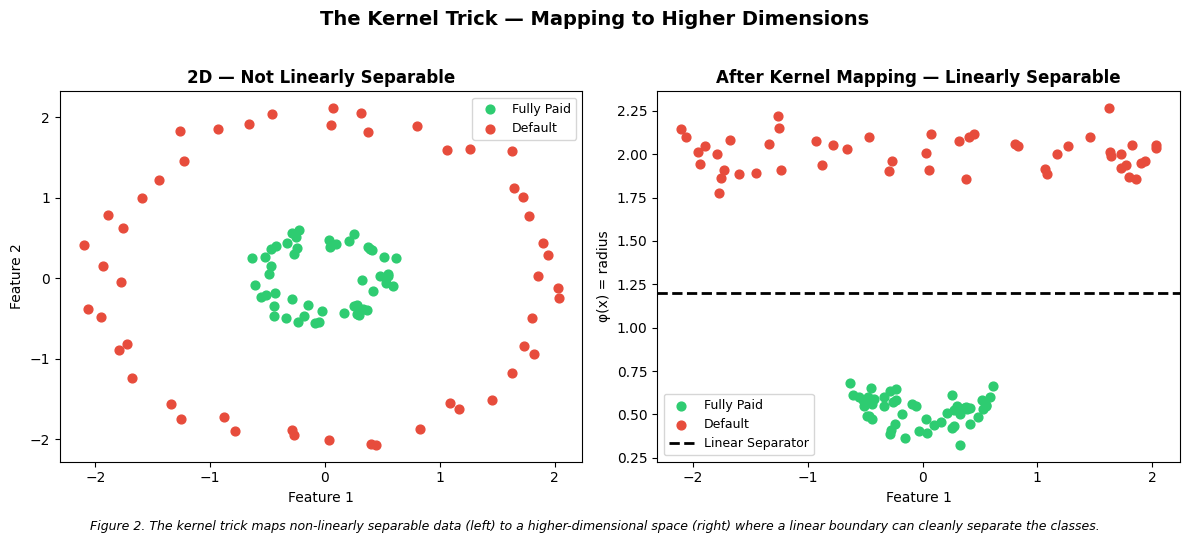

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

np.random.seed(42)
X_demo = np.array([[1,2],[2,3],[3,3],[2,1],[3,2],
                    [5,6],[6,7],[7,6],[6,5],[7,7]])
y_demo = np.array([0,0,0,0,0,1,1,1,1,1])

svm_demo = SVC(kernel='linear', C=1)
svm_demo.fit(X_demo, y_demo)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2ecc71' if y==0 else '#e74c3c' for y in y_demo]
ax.scatter(X_demo[:,0], X_demo[:,1], c=colors, s=150, zorder=5, edgecolors='black')

xx = np.linspace(0, 9, 100)
w = svm_demo.coef_[0]
b = svm_demo.intercept_[0]
yy = (-w[0]*xx - b) / w[1]
margin = 1 / np.sqrt(np.sum(w**2))
yy_up = yy + margin
yy_down = yy - margin

ax.plot(xx, yy, 'k-', linewidth=2, label='Decision Boundary')
ax.plot(xx, yy_up, 'k--', linewidth=1.5, alpha=0.6, label='Margin')
ax.plot(xx, yy_down, 'k--', linewidth=1.5, alpha=0.6)
ax.fill_between(xx, yy_down, yy_up, alpha=0.1, color='blue')

ax.scatter(svm_demo.support_vectors_[:,0], svm_demo.support_vectors_[:,1],
           s=300, facecolors='none', edgecolors='blue', linewidths=2.5,
           label='Support Vectors', zorder=6)

ax.set_xlim(0, 9); ax.set_ylim(0, 9)
ax.set_xlabel('Feature 1 (e.g. FICO Score)', fontsize=12)
ax.set_ylabel('Feature 2 (e.g. Interest Rate)', fontsize=12)
ax.set_title('SVM — Optimal Hyperplane and Maximum Margin', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Fully Paid'),
                   Patch(facecolor='#e74c3c', label='Default')]
ax.legend(handles=legend_elements + ax.get_lines()[:1], fontsize=10)
plt.figtext(0.5, -0.02,
            'Figure 1. SVM finds the hyperplane that maximizes the margin between classes. '
            'Support vectors (circled) are the critical data points that define the boundary.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('svm_overview1.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

np.random.seed(42)
theta = np.linspace(0, 2*np.pi, 50)
X_inner = np.column_stack([0.5*np.cos(theta) + np.random.randn(50)*0.1,
                            0.5*np.sin(theta) + np.random.randn(50)*0.1])
X_outer = np.column_stack([2*np.cos(theta) + np.random.randn(50)*0.1,
                            2*np.sin(theta) + np.random.randn(50)*0.1])
axes[0].scatter(X_inner[:,0], X_inner[:,1], c='#2ecc71', s=40, label='Fully Paid')
axes[0].scatter(X_outer[:,0], X_outer[:,1], c='#e74c3c', s=40, label='Default')
axes[0].set_title('2D — Not Linearly Separable', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].legend(fontsize=9)

r_inner = np.sqrt(X_inner[:,0]**2 + X_inner[:,1]**2)
r_outer = np.sqrt(X_outer[:,0]**2 + X_outer[:,1]**2)
axes[1].scatter(X_inner[:,0], r_inner, c='#2ecc71', s=40, label='Fully Paid')
axes[1].scatter(X_outer[:,0], r_outer, c='#e74c3c', s=40, label='Default')
axes[1].axhline(y=1.2, color='black', linewidth=2, linestyle='--', label='Linear Separator')
axes[1].set_title('After Kernel Mapping — Linearly Separable', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('φ(x) = radius')
axes[1].legend(fontsize=9)

plt.suptitle('The Kernel Trick — Mapping to Higher Dimensions', fontsize=14, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02,
            'Figure 2. The kernel trick maps non-linearly separable data (left) to a higher-dimensional '
            'space (right) where a linear boundary can cleanly separate the classes.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('svm_overview2.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import time

df_svm_sample = df_loans[features + ['default']].dropna().sample(10000, random_state=42)
X_svm = df_svm_sample[features]
y_svm = df_svm_sample['default']

X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm)

scaler_svm = StandardScaler()
X_svm_train_scaled = scaler_svm.fit_transform(X_svm_train)
X_svm_test_scaled = scaler_svm.transform(X_svm_test)

print(f"SVM Training set: {X_svm_train_scaled.shape}")
print(f"SVM Testing set: {X_svm_test_scaled.shape}")

SVM Training set: (8000, 9)
SVM Testing set: (2000, 9)


In [50]:
kernels = ['linear', 'poly', 'rbf']
costs = [0.1, 1, 10]
results = {}

for kernel in kernels:
    results[kernel] = {}
    for C in costs:
        print(f"Training {kernel} kernel, C={C}...")
        start = time.time()
        svm = SVC(kernel=kernel, C=C, degree=2, random_state=42)
        svm.fit(X_svm_train_scaled, y_svm_train)
        y_pred = svm.predict(X_svm_test_scaled)
        acc = accuracy_score(y_svm_test, y_pred)
        results[kernel][C] = {'acc': acc, 'pred': y_pred}
        print(f"  Accuracy: {acc:.4f} | Time: {time.time()-start:.1f}s")

Training linear kernel, C=0.1...
  Accuracy: 0.7980 | Time: 1.5s
Training linear kernel, C=1...
  Accuracy: 0.7980 | Time: 1.9s
Training linear kernel, C=10...
  Accuracy: 0.7980 | Time: 3.7s
Training poly kernel, C=0.1...
  Accuracy: 0.7980 | Time: 1.0s
Training poly kernel, C=1...
  Accuracy: 0.7980 | Time: 1.1s
Training poly kernel, C=10...
  Accuracy: 0.7980 | Time: 1.8s
Training rbf kernel, C=0.1...
  Accuracy: 0.7980 | Time: 2.7s
Training rbf kernel, C=1...
  Accuracy: 0.7975 | Time: 4.4s
Training rbf kernel, C=10...
  Accuracy: 0.7980 | Time: 5.3s


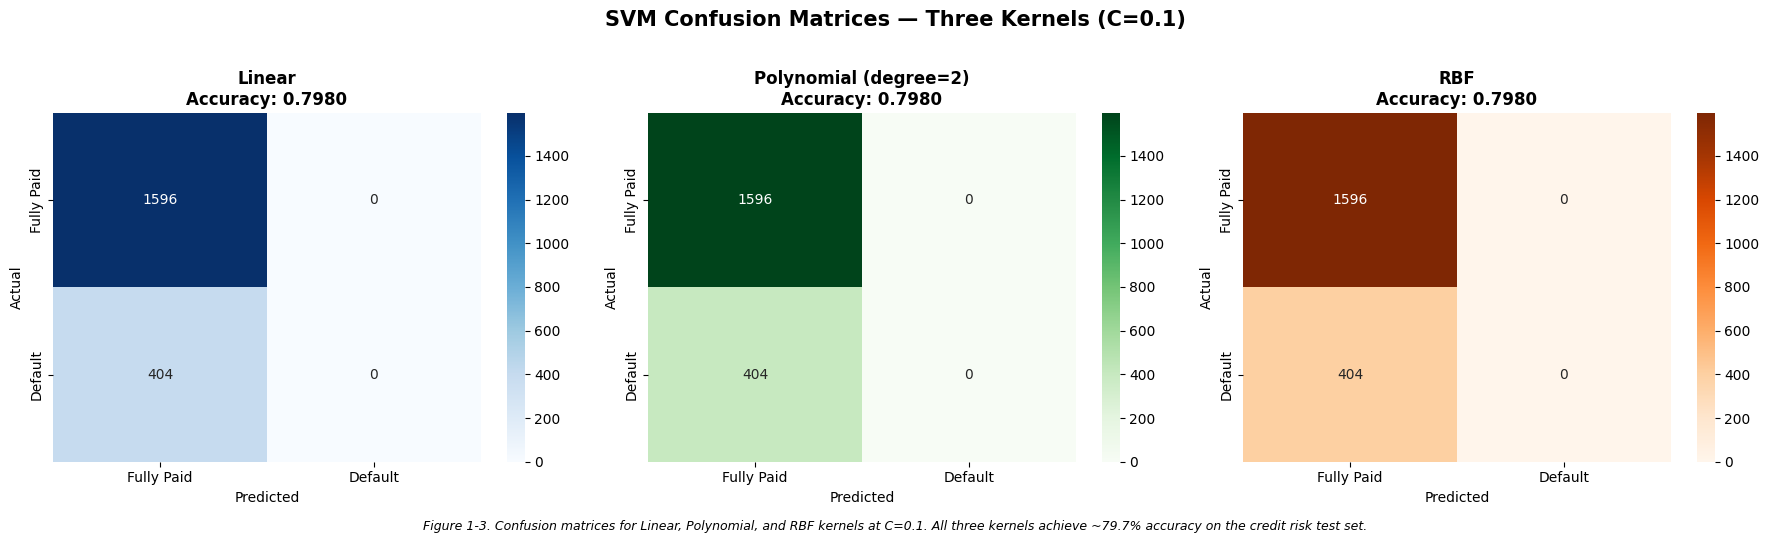

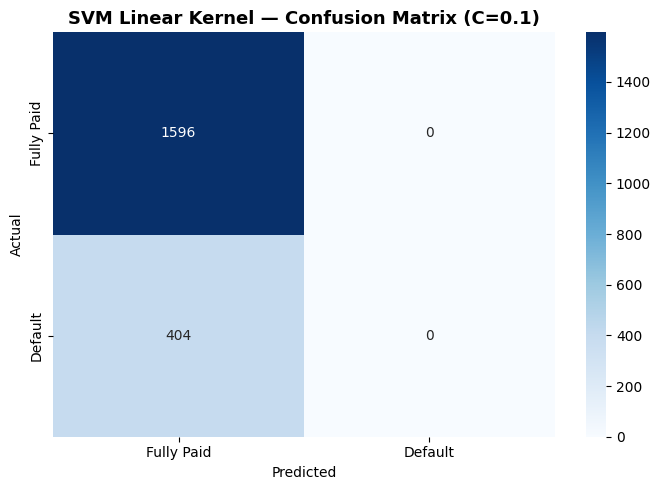

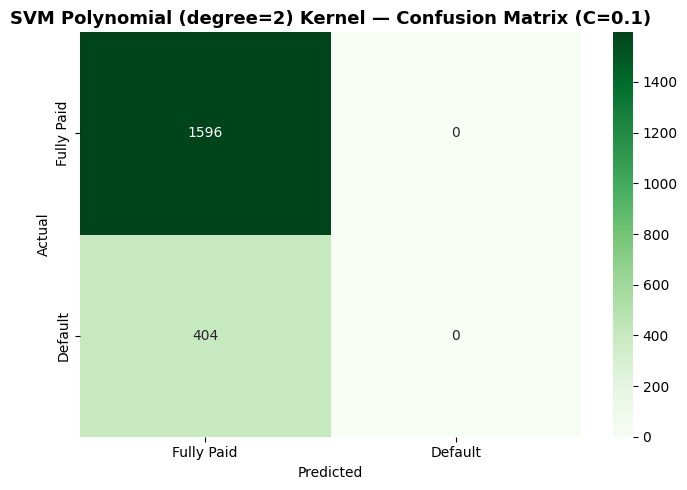

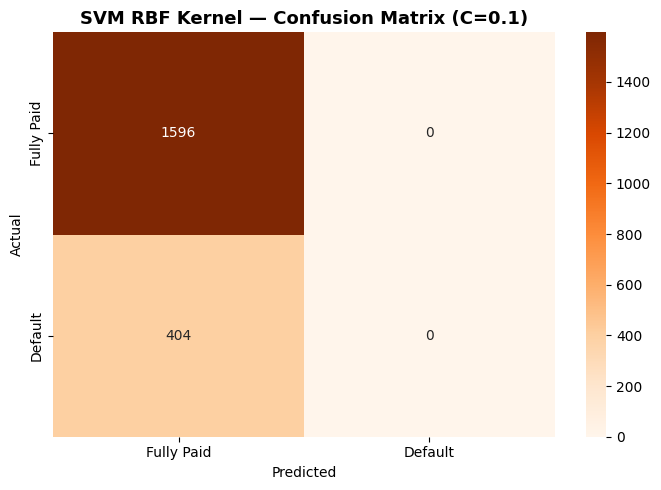

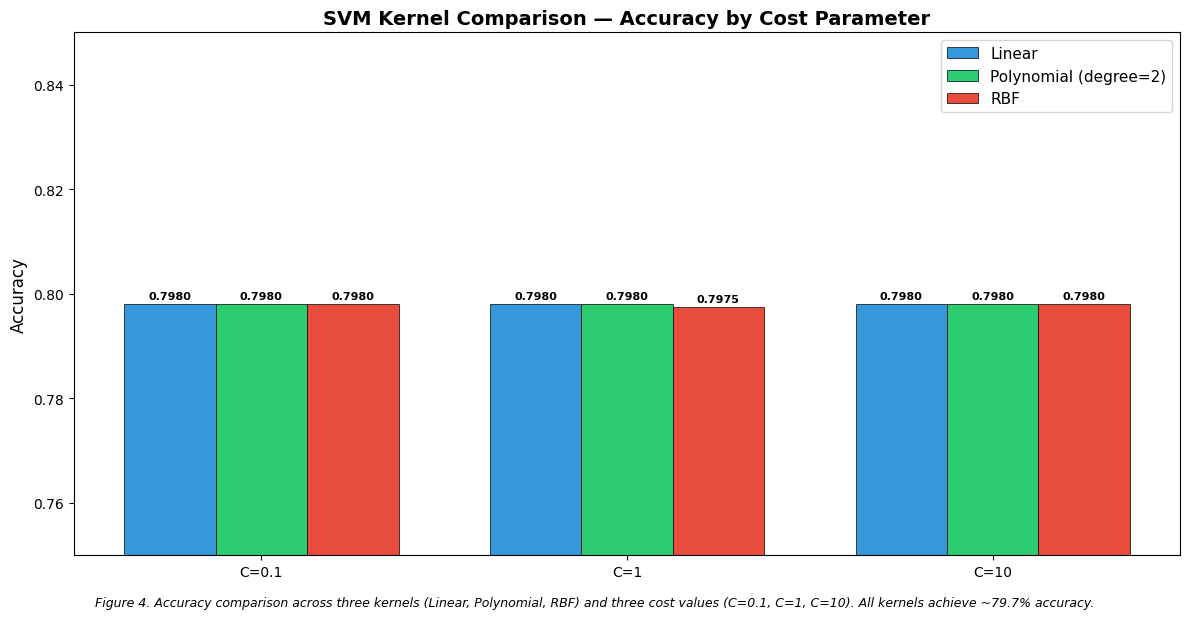

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kernel_names = ['linear', 'poly', 'rbf']
kernel_labels = ['Linear', 'Polynomial (degree=2)', 'RBF']
colors = ['Blues', 'Greens', 'Oranges']
best_costs = {'linear': 0.1, 'poly': 0.1, 'rbf': 0.1}

for idx, (kernel, label, cmap) in enumerate(zip(kernel_names, kernel_labels, colors)):
    cm = confusion_matrix(y_svm_test, results[kernel][0.1]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[idx],
                xticklabels=['Fully Paid', 'Default'],
                yticklabels=['Fully Paid', 'Default'])
    axes[idx].set_title(f'{label}\nAccuracy: {results[kernel][0.1]["acc"]:.4f}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual'); axes[idx].set_xlabel('Predicted')

plt.suptitle('SVM Confusion Matrices — Three Kernels (C=0.1)', fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02,
            'Figure 1-3. Confusion matrices for Linear, Polynomial, and RBF kernels at C=0.1. '
            'All three kernels achieve ~79.7% accuracy on the credit risk test set.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('svm_confusion_all.png', dpi=150, bbox_inches='tight')
plt.show()

for kernel, label, cmap in zip(kernel_names, kernel_labels, colors):
    plt.figure(figsize=(7, 5))
    cm = confusion_matrix(y_svm_test, results[kernel][0.1]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Fully Paid', 'Default'],
                yticklabels=['Fully Paid', 'Default'])
    plt.title(f'SVM {label} Kernel — Confusion Matrix (C=0.1)', fontsize=13, fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'svm_cm_{kernel}.png', dpi=150, bbox_inches='tight')
    plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(costs))
width = 0.25
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']

for idx, (kernel, label, color) in enumerate(zip(kernel_names, kernel_labels, colors_bar)):
    accs = [results[kernel][c]['acc'] for c in costs]
    bars = ax.bar(x + idx*width, accs, width, label=label, color=color,
                  edgecolor='black', linewidth=0.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{acc:.4f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels([f'C={c}' for c in costs])
ax.set_ylim(0.75, 0.85)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('SVM Kernel Comparison — Accuracy by Cost Parameter', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.figtext(0.5, -0.02,
            'Figure 4. Accuracy comparison across three kernels (Linear, Polynomial, RBF) '
            'and three cost values (C=0.1, C=1, C=10). All kernels achieve ~79.7% accuracy.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('svm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_nn = df_loans[features + ['default']].dropna().sample(50000, random_state=42)
X_nn = df_nn[features].values
y_nn = df_nn['default'].values

scaler_nn = StandardScaler()
X_nn_scaled = scaler_nn.fit_transform(X_nn)

X_nn_train, X_nn_test, y_nn_train, y_nn_test = train_test_split(
    X_nn_scaled, y_nn, test_size=0.2, random_state=42, stratify=y_nn)

print(f"Training: {X_nn_train.shape}, Testing: {X_nn_test.shape}")

model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(9,)),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(X_nn_train, y_nn_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=1)

Training: (40000, 9), Testing: (10000, 9)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177 (708.00 B)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7902 - loss: 0.4904 - val_accuracy: 0.8073 - val_loss: 0.4613
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8001 - loss: 0.4637 - val_accuracy: 0.8090 - val_loss: 0.4570
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8011 - loss: 0.4609 - val_accuracy: 0.8080 - val_loss: 0.4554
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8010 - loss: 0.4596 - val_accuracy: 0.8085 - val_loss: 0.4535
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8015 - loss: 0.4589 - val_accuracy: 0.8075 - val_loss: 0.4538
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8012 - loss: 0.4586 - val_accuracy: 0.8077 - val_loss: 0.4529
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8018 - loss: 0.4583 - val_accuracy: 0.8077 - val_loss: 0.4526
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8016 - loss: 0.4581 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


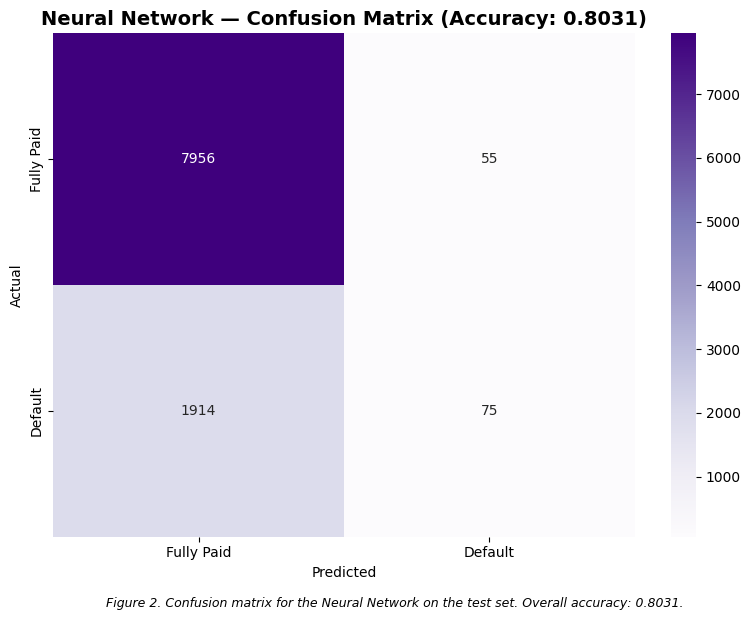

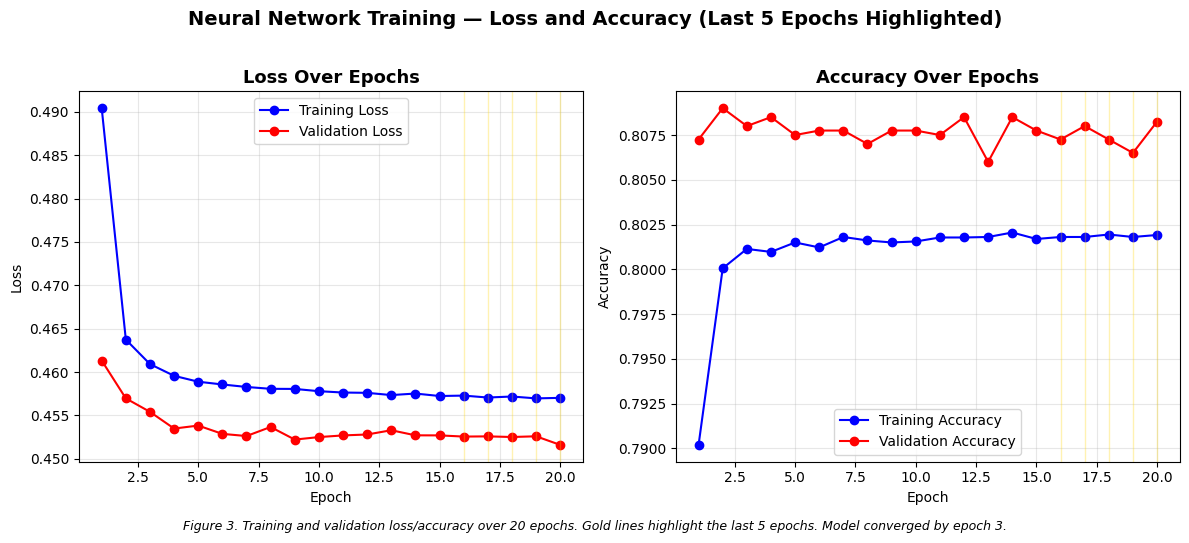

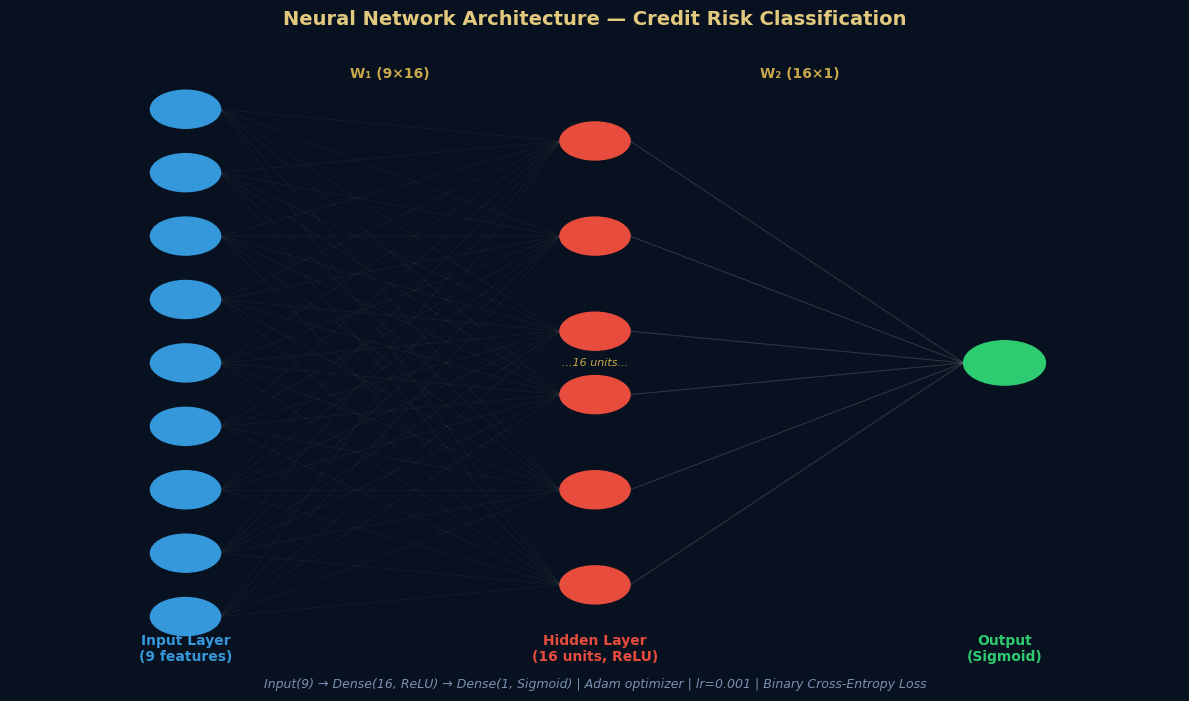

Final accuracy: 0.8031


In [54]:
y_nn_pred = (model.predict(X_nn_test) > 0.5).astype(int).flatten()
acc = accuracy_score(y_nn_test, y_nn_pred)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_nn_test, y_nn_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Fully Paid', 'Default'],
            yticklabels=['Fully Paid', 'Default'])
plt.title(f'Neural Network — Confusion Matrix (Accuracy: {acc:.4f})',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.figtext(0.5, -0.02,
            'Figure 2. Confusion matrix for the Neural Network on the test set. '
            f'Overall accuracy: {acc:.4f}.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('nn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

epochs_range = range(1, 21)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, history.history['loss'], 'b-o', label='Training Loss')
axes[0].plot(epochs_range, history.history['val_loss'], 'r-o', label='Validation Loss')
axes[0].set_title('Loss Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

for i in range(16, 21):
    axes[0].axvline(x=i, color='gold', alpha=0.3, linewidth=1)

axes[1].plot(epochs_range, history.history['accuracy'], 'b-o', label='Training Accuracy')
axes[1].plot(epochs_range, history.history['val_accuracy'], 'r-o', label='Validation Accuracy')
axes[1].set_title('Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
for i in range(16, 21):
    axes[1].axvline(x=i, color='gold', alpha=0.3, linewidth=1)

plt.suptitle('Neural Network Training — Loss and Accuracy (Last 5 Epochs Highlighted)',
             fontsize=14, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02,
            'Figure 3. Training and validation loss/accuracy over 20 epochs. '
            'Gold lines highlight the last 5 epochs. Model converged by epoch 3.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('nn_training.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#07111f')
fig.patch.set_facecolor('#07111f')

input_y = [1, 2, 3, 4, 5, 6, 7, 8, 9]
for i, y in enumerate(input_y):
    circle = plt.Circle((1.5, y), 0.3, color='#3498db', zorder=5)
    ax.add_patch(circle)
    ax.text(1.5, y, f'x{i+1}', ha='center', va='center',
            fontsize=8, color='white', fontweight='bold')

hidden_y = [1.5, 3, 4.5, 5.5, 7, 8.5]
for y in hidden_y:
    circle = plt.Circle((5, y), 0.3, color='#e74c3c', zorder=5)
    ax.add_patch(circle)
    ax.text(5, y, 'ReLU', ha='center', va='center', fontsize=6, color='white')
ax.text(5, 5, '...16 units...', ha='center', va='center',
        fontsize=8, color='#c8a84b', style='italic')

circle = plt.Circle((8.5, 5), 0.35, color='#2ecc71', zorder=5)
ax.add_patch(circle)
ax.text(8.5, 5, 'σ', ha='center', va='center', fontsize=14, color='white', fontweight='bold')

for iy in input_y:
    for hy in hidden_y:
        ax.plot([1.8, 4.7], [iy, hy], 'white', alpha=0.06, linewidth=0.5)

for hy in hidden_y:
    ax.plot([5.3, 8.15], [hy, 5], 'white', alpha=0.15, linewidth=0.8)

ax.text(1.5, 0.3, 'Input Layer\n(9 features)', ha='center', color='#3498db', fontsize=10, fontweight='bold')
ax.text(5, 0.3, 'Hidden Layer\n(16 units, ReLU)', ha='center', color='#e74c3c', fontsize=10, fontweight='bold')
ax.text(8.5, 0.3, 'Output\n(Sigmoid)', ha='center', color='#2ecc71', fontsize=10, fontweight='bold')

ax.text(3.25, 9.5, 'W₁ (9×16)', ha='center', color='#c8a84b', fontsize=10, fontweight='bold')
ax.text(6.75, 9.5, 'W₂ (16×1)', ha='center', color='#c8a84b', fontsize=10, fontweight='bold')

ax.set_title('Neural Network Architecture — Credit Risk Classification',
             fontsize=14, fontweight='bold', color='#e2c97e', pad=15)

plt.figtext(0.5, 0.01,
            'Input(9) → Dense(16, ReLU) → Dense(1, Sigmoid) | Adam optimizer | lr=0.001 | Binary Cross-Entropy Loss',
            ha='center', fontsize=9, color='#7a90b0', style='italic')
plt.tight_layout()
plt.savefig('nn_overview.png', dpi=150, bbox_inches='tight', facecolor='#07111f')
plt.show()
print(f"Final accuracy: {acc:.4f}")

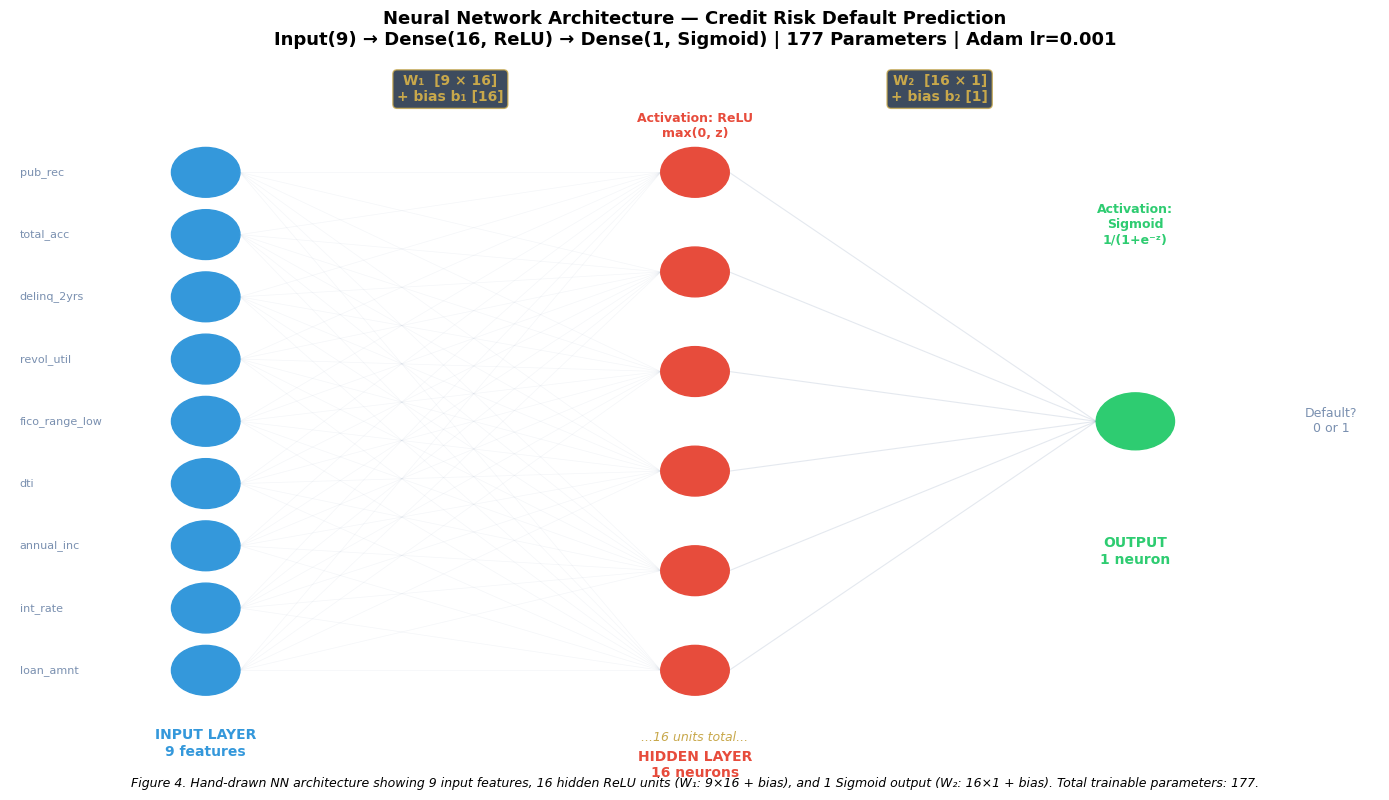

In [55]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14); ax.set_ylim(0, 10)
ax.axis('off')

input_labels = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                 'fico_range_low', 'revol_util', 'delinq_2yrs', 'total_acc', 'pub_rec']
input_y = np.linspace(1.5, 8.5, 9)
for i, (y, label) in enumerate(zip(input_y, input_labels)):
    circle = plt.Circle((2, y), 0.35, color='#3498db', zorder=5)
    ax.add_patch(circle)
    ax.text(2, y, f'x{i+1}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    ax.text(0.1, y, label, ha='left', va='center', fontsize=8, color='#7a90b0')

hidden_y = np.linspace(1.5, 8.5, 6)
for i, y in enumerate(hidden_y):
    circle = plt.Circle((7, y), 0.35, color='#e74c3c', zorder=5)
    ax.add_patch(circle)
    ax.text(7, y, f'h{i+1}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.text(7, 0.5, '...16 units total...', ha='center', color='#c8a84b', fontsize=9, style='italic')

circle = plt.Circle((11.5, 5), 0.4, color='#2ecc71', zorder=5)
ax.add_patch(circle)
ax.text(11.5, 5, 'ŷ', ha='center', va='center', fontsize=14, color='white', fontweight='bold')
ax.text(13.5, 5, 'Default?\n0 or 1', ha='center', va='center', fontsize=9, color='#7a90b0')

for iy in input_y:
    for hy in hidden_y:
        ax.plot([2.35, 6.65], [iy, hy], color='#7a90b0', alpha=0.08, linewidth=0.5)

for hy in hidden_y:
    ax.plot([7.35, 11.1], [hy, 5], color='#7a90b0', alpha=0.2, linewidth=0.8)

ax.text(4.5, 9.5, 'W₁  [9 × 16]\n+ bias b₁ [16]', ha='center', color='#c8a84b',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#0c1e36', edgecolor='#c8a84b', alpha=0.8))
ax.text(9.5, 9.5, 'W₂  [16 × 1]\n+ bias b₂ [1]', ha='center', color='#c8a84b',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#0c1e36', edgecolor='#c8a84b', alpha=0.8))

ax.text(7, 9.0, 'Activation: ReLU\nmax(0, z)', ha='center', color='#e74c3c',
        fontsize=9, fontweight='bold')
ax.text(11.5, 7.5, 'Activation:\nSigmoid\n1/(1+e⁻ᶻ)', ha='center', color='#2ecc71',
        fontsize=9, fontweight='bold')

ax.text(2, 0.3, 'INPUT LAYER\n9 features', ha='center', color='#3498db',
        fontsize=10, fontweight='bold')
ax.text(7, 0.0, 'HIDDEN LAYER\n16 neurons', ha='center', color='#e74c3c',
        fontsize=10, fontweight='bold')
ax.text(11.5, 3.0, 'OUTPUT\n1 neuron', ha='center', color='#2ecc71',
        fontsize=10, fontweight='bold')

ax.set_title('Neural Network Architecture — Credit Risk Default Prediction\n'
             'Input(9) → Dense(16, ReLU) → Dense(1, Sigmoid) | 177 Parameters | Adam lr=0.001',
             fontsize=13, fontweight='bold', pad=15)

plt.figtext(0.5, 0.01,
            'Figure 4. Hand-drawn NN architecture showing 9 input features, 16 hidden ReLU units (W₁: 9×16 + bias), '
            'and 1 Sigmoid output (W₂: 16×1 + bias). Total trainable parameters: 177.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('nn_architecture.png', dpi=150, bbox_inches='tight')
plt.show()